In [1]:
from pathlib import Path
import sys

_here = Path.cwd().resolve()
_candidates = (_here, *_here.parents)
REPO_ROOT = next((candidate for candidate in _candidates if (candidate / "m33_pipeline").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root from {Path.cwd()}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from m33_pipeline.notebook_setup import prepare_notebook

REPO_ROOT = prepare_notebook(REPO_ROOT)
print(f"Notebook working directory set to: {REPO_ROOT}")

Notebook working directory set to: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import astropy.constants as c
import pyneb as pn
import matplotlib.pyplot as plt
HAS_PYNEB=True
from astropy.coordinates import SkyCoord, SkyOffsetFrame
from astropy.visualization import AsinhStretch, PercentileInterval
from skimage.segmentation import find_boundaries
from matplotlib import cm
from skimage.measure import find_contours
from matplotlib.patches import ConnectionPatch
from scipy.optimize import curve_fit
from types import SimpleNamespace
import os
import shutil
import re
import matplotlib as mpl
import seaborn as sns

from m33_pipeline.reporting import (
    add_fit_values,
    add_duplicate_region_values,
    add_halpha_flux_partition_values,
    build_catalog_number_values,
    format_value,
    load_snr_catalog,
    load_wr_catalog,
)
from m33_pipeline.planetary_nebulae import crossmatch_pne_to_hii_boundaries

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

plt.rcParams["text.usetex"] = False

plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=20)

plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

from m33_pipeline import paths


In [3]:
# Notebook 8 uses the published machine-readable catalog as its input.
catalog_method = 'summed_map'
catalog_dig_mode = 'dig_subtracted'
# Choose which extinction-corrected flux set downstream plots should use.
# Options: 'digsub_dered' or 'nodig_dered'.
CATALOG_FLUX_VERSION = 'digsub_dered'
field_catalog_pattern = f"flux_catalogs/{catalog_method}/{catalog_dig_mode}/flux_catalog_{{FIELD}}.csv"
primary_only = True
plot_root = Path('PAPER_PLOTS') / catalog_method / catalog_dig_mode
plot_root.mkdir(parents=True, exist_ok=True)
PUBLISHED_CATALOG_PATH = plot_root / 'tables' / 'M33_emission_region_properties.csv'

cat = pd.read_csv(PUBLISHED_CATALOG_PATH)
cat_before_primary_filter = cat.copy()

# Compatibility aliases for plotting code originally written against the pipeline catalog.
if 'field' not in cat.columns and 'Field' in cat.columns:
    cat['field'] = cat['Field']
if 'region_id' not in cat.columns and 'ID' in cat.columns:
    cat['region_id'] = cat['ID']


def _augment_missing_metallicity_columns_from_pipeline_catalog(base_df):
    z_cols = [col for col in base_df.columns if col.startswith('Z_')]
    if z_cols:
        return base_df
    source_path = paths.combined_catalog_csv(catalog_method, catalog_dig_mode)
    if not source_path.exists():
        print(f'Metallicity columns missing from published catalog and pipeline catalog not found: {source_path}')
        return base_df
    source = pd.read_csv(source_path)
    key_cols = ['field', 'region_id']
    if not set(key_cols).issubset(base_df.columns) or not set(key_cols).issubset(source.columns):
        print(f'Metallicity columns missing, but cannot merge pipeline catalog because key columns are unavailable in {source_path}')
        return base_df
    missing_z_cols = [col for col in source.columns if col.startswith('Z_') and col not in base_df.columns]
    if not missing_z_cols:
        print(f'Metallicity columns missing from published catalog, and no Z_* columns found in {source_path}')
        return base_df
    merged = base_df.merge(
        source[key_cols + missing_z_cols],
        on=key_cols,
        how='left',
        validate='many_to_one',
    )
    print(f'Added {len(missing_z_cols)} metallicity columns from {source_path}')
    return merged


cat = _augment_missing_metallicity_columns_from_pipeline_catalog(cat)

if 'x' not in cat.columns:
    cat['x'] = np.nan
if 'y' not in cat.columns:
    cat['y'] = np.nan

_aliases = {
    'N_spaxels': 'npix_region',
    'R_c_pc': 'radius_areaeq_pc',
    'R_16_pc': 'radius_p16_pc',
    'R_50_pc': 'radius_p50_pc',
    'R_84_pc': 'radius_p84_pc',
    'A_V_mag': 'sum_A_V',
    'E_BV_mag': 'sum_E_BV',
    'BPT_class': 'BPT_class_sum_dered',
    'L_Halpha_raw': 'L_Ha_sum',
    'L_Halpha_dered': 'L_Ha_sum_dered_nodig',
    'L_Halpha_bgsub': 'L_Ha_sum_dered',
    'ne': 'ne_SII_cm3',
    'ne_err_minus': 'ne_SII_cm3_mc_minus',
    'ne_err_plus': 'ne_SII_cm3_mc_plus',
    'Pthermal': 'P_thermal_SII_over_k_K_cm3',
    'Pthermal_err_minus': 'P_thermal_SII_over_k_K_cm3_mc_minus',
    'Pthermal_err_plus': 'P_thermal_SII_over_k_K_cm3_mc_plus',
    'logU_KK04_err': 'logU_KK04_e',
    'has_WR': 'has_wr_in_boundary',
    'has_SNR': 'has_snr_in_boundary',
    'has_PN': 'has_pn_in_boundary',
}
for source, target in _aliases.items():
    if source in cat.columns and target not in cat.columns:
        cat[target] = cat[source]

# Compatibility defaults for columns that existed in the pipeline catalog but are
# summarized or omitted in the published paper table.
if 'ne_SII_reliable' not in cat.columns:
    ne_values = pd.to_numeric(cat['ne_SII_cm3'], errors='coerce') if 'ne_SII_cm3' in cat.columns else pd.Series(np.nan, index=cat.index)
    cat['ne_SII_reliable'] = np.isfinite(ne_values) & (ne_values > 0)

if 'n_pn_in_boundary' not in cat.columns:
    if 'has_pn_in_boundary' in cat.columns:
        cat['n_pn_in_boundary'] = cat['has_pn_in_boundary'].fillna(False).astype(bool).astype(int)
    else:
        cat['n_pn_in_boundary'] = 0

for bool_col in ['has_wr_in_boundary', 'has_snr_in_boundary', 'has_pn_in_boundary']:
    if bool_col not in cat.columns:
        cat[bool_col] = False
    else:
        cat[bool_col] = cat[bool_col].fillna(False).astype(bool)


for line in ['Halpha', 'Hbeta', '[OIII]5007', '[NII]6583', '[SII]6716', '[SII]6731', '[OII]3727']:
    for source_suffix, target_suffix in [
        ('flux_raw', 'sum_nodig'),
        ('flux_dered', 'sum_dered_nodig'),
        ('flux_bgsub', 'sum_dered'),
        ('flux_err', 'e_sum'),
        ('SNR', 'SNR_sum'),
    ]:
        source = f'{line}_{source_suffix}'
        if target_suffix == 'SNR_sum':
            target = f'SNR_{line}_sum'
        elif target_suffix == 'e_sum':
            target = f'F_{line}_e_sum'
        else:
            target = f'F_{line}_{target_suffix}'
        if source in cat.columns and target not in cat.columns:
            cat[target] = cat[source]
    dered = f'{line}_flux_dered'
    bgsub = f'{line}_flux_bgsub'
    if dered in cat.columns and f'F_{line}_sum_dered_nodig' not in cat.columns:
        cat[f'F_{line}_sum_dered_nodig'] = cat[dered]
    if bgsub in cat.columns and f'F_{line}_sum_dered_digsub' not in cat.columns:
        cat[f'F_{line}_sum_dered_digsub'] = cat[bgsub]
    chosen_dered = f'F_{line}_sum_dered_digsub' if CATALOG_FLUX_VERSION == 'digsub_dered' else f'F_{line}_sum_dered_nodig'
    if chosen_dered in cat.columns:
        cat[f'F_{line}_sum_dered'] = cat[chosen_dered]
    raw = f'{line}_flux_raw'
    if raw in cat.columns and f'F_{line}_sum' not in cat.columns:
        cat[f'F_{line}_sum'] = cat[bgsub] if bgsub in cat.columns else cat[raw]

if CATALOG_FLUX_VERSION not in {'digsub_dered', 'nodig_dered'}:
    raise ValueError(f"Unknown CATALOG_FLUX_VERSION: {CATALOG_FLUX_VERSION!r}")


def positive_halpha_snr_catalog(df, label='catalog', quiet=False):
    snr_col = next((col for col in [
        'SNR_Halpha_sum',
        'SNR_Halpha_sum_nodig',
        'Halpha_SNR',
        'Halpha_SNR_raw',
        'Halpha_SNR_obs',
    ] if col in df.columns), None)
    if snr_col is None:
        raise KeyError('Cannot apply Halpha S/N > 0 catalog cut: no Halpha S/N column found.')
    snr_values = pd.to_numeric(df[snr_col], errors='coerce')
    out = df.loc[snr_values > 0].copy().reset_index(drop=True)
    if not quiet:
        print(f'Halpha S/N > 0 filtering for {label} using {snr_col}: kept {len(out)} / {len(df)} rows.')
    return out
cat = positive_halpha_snr_catalog(cat, label='notebook 8 plotting catalog')

print(f'Notebook 8 using {CATALOG_FLUX_VERSION} fluxes for F_<line>_sum_dered plotting columns.')
if CATALOG_FLUX_VERSION == 'nodig_dered' and 'L_Ha_sum_dered_nodig' in cat.columns:
    cat['L_Ha_sum_dered'] = cat['L_Ha_sum_dered_nodig']
elif CATALOG_FLUX_VERSION == 'digsub_dered' and 'L_Halpha_bgsub' in cat.columns:
    cat['L_Ha_sum_dered'] = cat['L_Halpha_bgsub']

# Log-luminosity aliases expected by the original plotting cells.
for linear_col in ['L_Ha_sum', 'L_Ha_sum_dered_nodig', 'L_Ha_sum_dered', 'radius_areaeq_pc']:
    log_col = f'log_{linear_col}'
    if linear_col in cat.columns and log_col not in cat.columns:
        values = pd.to_numeric(cat[linear_col], errors='coerce').to_numpy(dtype=float)
        with np.errstate(divide='ignore', invalid='ignore'):
            cat[log_col] = np.where(values > 0, np.log10(values), np.nan)

if 'P_thermal_SII_over_k_K_cm3' in cat.columns and 'log_P_thermal_SII_over_k' not in cat.columns:
    values = pd.to_numeric(cat['P_thermal_SII_over_k_K_cm3'], errors='coerce').to_numpy(dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        cat['log_P_thermal_SII_over_k'] = np.where(values > 0, np.log10(values), np.nan)

# Compute deprojected radius if the published catalog does not include it.
if 'R_gal_kpc' not in cat.columns and {'RA_deg', 'Dec_deg'}.issubset(cat.columns):
    M33_CENTER = SkyCoord('01h33m50.9s', '+30d39m36.8s', frame='icrs')
    M33_INCL = np.deg2rad(56.0)
    M33_PA = np.deg2rad(23.0)
    M33_D_KPC = 840.0
    coords = SkyCoord(ra=cat['RA_deg'].to_numpy(dtype=float) * u.deg,
                      dec=cat['Dec_deg'].to_numpy(dtype=float) * u.deg,
                      frame='icrs')
    off = coords.transform_to(SkyOffsetFrame(origin=M33_CENTER))
    x_east_kpc = off.lon.to(u.radian).value * M33_D_KPC
    y_north_kpc = off.lat.to(u.radian).value * M33_D_KPC
    sinPA, cosPA = np.sin(M33_PA), np.cos(M33_PA)
    x_major = x_east_kpc * sinPA + y_north_kpc * cosPA
    y_minor = x_east_kpc * cosPA - y_north_kpc * sinPA
    cat['R_gal_kpc'] = np.sqrt(x_major**2 + (y_minor / np.cos(M33_INCL))**2)

if primary_only and 'primary' in cat.columns:
    cat = cat.loc[cat['primary'].fillna(True)].copy().reset_index(drop=True)

def paper_plot_path(filename, subdir=None):
    outdir = plot_root if subdir is None else plot_root / subdir
    outdir.mkdir(parents=True, exist_ok=True)
    return outdir / filename


_required_plot_columns = [
    'field', 'region_id', 'R_gal_kpc', 'sum_A_V', 'L_Ha_sum_dered',
    'log_L_Ha_sum_dered', 'ne_SII_cm3', 'ne_SII_reliable',
    'P_thermal_SII_over_k_K_cm3', 'log_P_thermal_SII_over_k',
    'radius_areaeq_pc', 'radius_p50_pc', 'log_radius_areaeq_pc',
    'has_wr_in_boundary', 'has_snr_in_boundary', 'has_pn_in_boundary',
    'n_pn_in_boundary', 'BPT_class_sum_dered',
]
_missing_plot_columns = [col for col in _required_plot_columns if col not in cat.columns]
if _missing_plot_columns:
    raise KeyError(f'Missing notebook-8 plotting compatibility columns: {_missing_plot_columns}')

print(f'Loaded published catalog from {PUBLISHED_CATALOG_PATH} with {len(cat)} rows and {len(cat.columns)} plotting-compatible columns.')


Halpha S/N > 0 filtering for notebook 8 plotting catalog using SNR_Halpha_sum: kept 5893 / 5893 rows.
Notebook 8 using digsub_dered fluxes for F_<line>_sum_dered plotting columns.
Loaded published catalog from PAPER_PLOTS/summed_map/dig_subtracted/tables/M33_emission_region_properties.csv with 5893 rows and 187 plotting-compatible columns.


In [4]:
# Load PN catalog for map overlays. Notebook 8 is read-only with respect to the catalog,
# so this does not update or rewrite the published HII-region table.
pn_catalog_path = Path('CATALOGS/planetary_nebulae/M33_PNe_combined_deduplicated.csv')
if pn_catalog_path.exists():
    pn_catalog = pd.read_csv(pn_catalog_path)
    print(f'Loaded PN catalog from {pn_catalog_path} with {len(pn_catalog)} rows.')
else:
    pn_catalog = pd.DataFrame()
    print(f'PN catalog not found: {pn_catalog_path}')


Loaded PN catalog from CATALOGS/planetary_nebulae/M33_PNe_combined_deduplicated.csv with 187 rows.


In [5]:
# Star-forming region definition used throughout this notebook.
# Change this one block, then rerun the notebook to switch the selection.
#
# Examples:
#   STAR_FORMING_DEFINITION = {"mode": "bpt"}
#   STAR_FORMING_DEFINITION = {"mode": "sii_ha", "sii_ha_max": 0.4}
#
# For sii_ha mode, sii_ha_max is the linear ratio
# ([SII]6716 + [SII]6731) / Halpha.
STAR_FORMING_DEFINITION = {
    "mode": "bpt",             # options: "bpt", "sii_ha"
    "sii_ha_max": 0.4,      # used only when mode == "sii_ha"
}
STAR_FORMING_SNR_CUT = 3.0


def _first_present_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def _numeric_column(df, candidates):
    col = _first_present_column(df, candidates)
    if col is None:
        return np.full(len(df), np.nan, dtype=float), None
    return pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float), col


def _selected_sii_ha_ratio(df):
    ha, ha_col = _numeric_column(df, [
        "F_Halpha_sum_dered",
        "F_Halpha_sum_digsub",
        "F_Halpha_sum",
        "F_Halpha_sum_nodig",
    ])
    sii6716, sii6716_col = _numeric_column(df, [
        "F_[SII]6716_sum_dered",
        "F_[SII]6716_sum_digsub",
        "F_[SII]6716_sum",
        "F_[SII]6716_sum_nodig",
    ])
    sii6731, sii6731_col = _numeric_column(df, [
        "F_[SII]6731_sum_dered",
        "F_[SII]6731_sum_digsub",
        "F_[SII]6731_sum",
        "F_[SII]6731_sum_nodig",
    ])
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = (sii6716 + sii6731) / ha
    ratio = np.where(np.isfinite(ratio) & (ha > 0) & (sii6716 > 0) & (sii6731 > 0), ratio, np.nan)
    return ratio, {"Halpha": ha_col, "SII6716": sii6716_col, "SII6731": sii6731_col}


def selected_star_forming_mask(df, definition=None):
    definition = dict(STAR_FORMING_DEFINITION if definition is None else definition)
    mode = str(definition.get("mode", "bpt")).strip().lower()
    if mode == "bpt":
        if "BPT_class_sum_dered" not in df.columns:
            return np.zeros(len(df), dtype=bool)
        return df["BPT_class_sum_dered"].astype(str).str.strip().eq("Star-forming").to_numpy(dtype=bool)
    if mode == "sii_ha":
        ratio, _ = _selected_sii_ha_ratio(df)
        max_ratio = float(definition.get("sii_ha_max", 0.4))
        return np.isfinite(ratio) & (ratio < max_ratio)
    raise ValueError(f"Unknown STAR_FORMING_DEFINITION mode: {mode!r}")


def selected_star_forming_snr_mask(df, snr_cut=None, definition=None):
    snr_cut = STAR_FORMING_SNR_CUT if snr_cut is None else snr_cut
    if "all_lines_snr_mask" in globals():
        snr_mask = all_lines_snr_mask(df, snr_cut=snr_cut)
    elif "_all_bpt_lines_snr_mask_for_plotting" in globals():
        snr_mask = _all_bpt_lines_snr_mask_for_plotting(df, snr_cut=snr_cut)
    else:
        snr_cols = [
            "SNR_Halpha_sum",
            "SNR_Hbeta_sum",
            "SNR_[OIII]5007_sum",
            "SNR_[SII]6716_sum",
            "SNR_[NII]6583_sum",
        ]
        snr_mask = np.ones(len(df), dtype=bool)
        for col in snr_cols:
            if col not in df.columns:
                snr_mask &= False
            else:
                snr_mask &= pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float) > snr_cut
    primary = df["primary"].fillna(True).astype(bool).to_numpy() if "primary" in df.columns else np.ones(len(df), dtype=bool)
    return selected_star_forming_mask(df, definition=definition) & snr_mask & primary


def star_forming_definition_label(definition=None):
    definition = dict(STAR_FORMING_DEFINITION if definition is None else definition)
    mode = str(definition.get("mode", "bpt")).strip().lower()
    if mode == "bpt":
        return "BPT star-forming"
    if mode == "sii_ha":
        return rf"[SII]/H$\alpha$ < {float(definition.get('sii_ha_max', 0.4)):.2f}"
    return mode

cat["selected_star_forming"] = selected_star_forming_mask(cat)
cat["selected_star_forming_snr"] = selected_star_forming_snr_mask(cat, snr_cut=STAR_FORMING_SNR_CUT)
print(f"Star-forming definition: {star_forming_definition_label()}")
print(f"Selected star-forming regions: {int(cat['selected_star_forming'].sum())} / {len(cat)}")
print(f"Selected star-forming regions with all-line S/N > {STAR_FORMING_SNR_CUT:g}: {int(cat['selected_star_forming_snr'].sum())} / {len(cat)}")

# Accumulates linear-fit outputs from the paper radial/scaling plot cells.
radial_gradient_fit_results = {}


Star-forming definition: BPT star-forming
Selected star-forming regions: 5134 / 5893
Selected star-forming regions with all-line S/N > 3: 4578 / 5893


In [ ]:

# Functions to plot each map with boundaries colored by BPT class, and WR/SNR locations overlaid.

def field_to_fieldnum(field_label: str) -> str:
    """
    Map your plot field labels to WR catalog Field codes.
    Input examples: 'NE','NW','SE','SW','F5'...'F9'
    Output: 'F1'...'F9'
    """
    mapping = {"NE": "F1", "NW": "F2", "SE": "F3", "SW": "F4"}
    return mapping.get(field_label, field_label)  # F5->F5 etc.


def parse_name_to_coords(name: str) -> SkyCoord:
    # Example: 'J013307.80+302951.1'
    ra_h = name[1:3]
    ra_m = name[3:5]
    ra_s = name[5:10]
    dec_sign = name[10]
    dec_d = name[11:13]
    dec_m = name[13:15]
    dec_s = name[15:]
    ra_str = f"{ra_h}h{ra_m}m{ra_s}s"
    dec_str = f"{dec_sign}{dec_d}d{dec_m}m{dec_s}s"
    return SkyCoord(ra_str, dec_str, frame="icrs")

# ha_fits_path = "M33_Halpha.fits"
def load_halpha_log_and_wcs(wcs: str):
    with fits.open(wcs) as hdul:
        data = hdul[0].data
        hdr = hdul[0].header

    data = np.where(np.isfinite(data), data, np.nan)

    with np.errstate(divide="ignore", invalid="ignore"):
        ha_log = np.log10(data)
    ha_log = np.where(np.isfinite(ha_log), ha_log, np.nan)

    wcs = WCS(hdr)
    return ha_log, wcs


def try_load_boundary_map(field_label: str, boundary_dir="boundary_map"):
    """
    Tries boundary_map/Boundary_map_{FIELD}.fits where FIELD is e.g. NE, NW, SE, SW, F5...
    Returns array or None if missing/unreadable.
    """
    path = os.path.join(boundary_dir, f"Boundary_map_{field_label}.fits")
    if not os.path.exists(path):
        return None
    try:
        return fits.getdata(path)
    except Exception:
        return None


def get_wr_pixels_for_field(wr_catalog: pd.DataFrame, field_num: str, wcs: WCS):
    wr_field = wr_catalog[wr_catalog["Field"] == field_num]
    if len(wr_field) == 0:
        return np.array([]), np.array([])

    coords = [parse_name_to_coords(n) for n in wr_field["Name (star)"]]
    sky = SkyCoord(coords)
    x_wr, y_wr = wcs.world_to_pixel(sky)
    return np.array(x_wr), np.array(y_wr)


def get_snr_pixels_for_field(snr_catalog: pd.DataFrame, wcs: WCS, xlim=(50, 2000), ylim=(50, 2000)):
    """
    Your snr_table.csv loaded with pd.read_csv.
    This assumes columns named exactly 'RA' and 'Dec' OR 'Dec'/'DEC' variants.
    """
    # Be forgiving about Dec column name
    if "Dec" in snr_catalog.columns:
        dec_col = "Dec"
    elif "DEC" in snr_catalog.columns:
        dec_col = "DEC" 
    elif "dec" in snr_catalog.columns:
        dec_col = "dec"
    else:
        raise KeyError("SNR catalog must have a Dec/DEC column (plus RA).")

    if "RA" not in snr_catalog.columns:
        raise KeyError("SNR catalog must have an 'RA' column.")

    coords = SkyCoord(snr_catalog["RA"].astype(str),
                      snr_catalog[dec_col].astype(str),
                      unit=(u.hourangle, u.deg))

    x_snr, y_snr = wcs.world_to_pixel(coords)
    x_snr = np.array(x_snr)
    y_snr = np.array(y_snr)

    in_field = (x_snr > xlim[0]) & (x_snr < xlim[1]) & (y_snr > ylim[0]) & (y_snr < ylim[1])
    return x_snr[in_field], y_snr[in_field]


def get_pn_pixels_for_field(pn_catalog: pd.DataFrame, wcs: WCS, xlim=(50, 2000), ylim=(50, 2000)):
    """Return all catalogued PN positions that fall inside the field image limits."""
    if pn_catalog is None or len(pn_catalog) == 0:
        return np.array([]), np.array([])
    if {"RA_deg", "Dec_deg"}.issubset(pn_catalog.columns):
        coords = SkyCoord(
            pn_catalog["RA_deg"].to_numpy(dtype=float) * u.deg,
            pn_catalog["Dec_deg"].to_numpy(dtype=float) * u.deg,
            frame="icrs",
        )
    elif {"RA", "Dec"}.issubset(pn_catalog.columns):
        coords = SkyCoord(pn_catalog["RA"].astype(str), pn_catalog["Dec"].astype(str), unit=(u.hourangle, u.deg))
    else:
        raise KeyError("PN catalog must have RA_deg/Dec_deg or RA/Dec columns.")

    x_pn, y_pn = wcs.world_to_pixel(coords)
    x_pn = np.array(x_pn)
    y_pn = np.array(y_pn)
    in_field = (x_pn > xlim[0]) & (x_pn < xlim[1]) & (y_pn > ylim[0]) & (y_pn < ylim[1])
    return x_pn[in_field], y_pn[in_field]


def _first_existing_path(paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None


def _clean_bpt_class(val):
    if pd.isna(val):
        return "Unclassified"
    val = str(val).strip()
    if val == "" or val.lower() == "nan":
        return "Unclassified"
    return val


def _load_image_and_wcs_separately(image_path, wcs_path=None):
    """
    Load image data from image_path and WCS from wcs_path.
    If wcs_path is None, use the image header for WCS too.
    """
    image_data = np.squeeze(fits.getdata(image_path)).astype(float)

    if wcs_path is None:
        wcs_header = fits.getheader(image_path)
    else:
        wcs_header = fits.getheader(wcs_path)

    wcs = WCS(wcs_header)
    return image_data, wcs


def _safe_log10_image(data):
    """
    Take log10 safely: non-positive values become NaN.
    """
    out = np.full_like(data, np.nan, dtype=float)
    good = np.isfinite(data) & (data > 0)
    out[good] = np.log10(data[good])
    return out


def _finite_sum_mosaic(*arrays):
    """Sum mosaics while preserving pixels that are finite in at least one input."""
    arrays = [np.asarray(arr, dtype=float) for arr in arrays if arr is not None]
    if not arrays:
        return None
    finite_any = np.zeros(arrays[0].shape, dtype=bool)
    summed = np.zeros(arrays[0].shape, dtype=float)
    for arr in arrays:
        finite = np.isfinite(arr)
        finite_any |= finite
        summed += np.where(finite, arr, 0.0)
    summed[~finite_any] = np.nan
    return summed


def _plot_bpt_boundaries_fast(
    ax,
    label_map,
    catalog,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    lw=0.5,
    alpha=0.9,
    zorder=3,
    valid_mask=None,
):
    """
    Faster boundary plotting:
    group region IDs by BPT class, then contour once per class.
    """
    if class_colors is None:
        class_colors = {
            "Star-forming": "blue",
            "Composite": "green",
            "AGN/Shock": "red",
            "Unclassified": "gray",
        }

    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)

    if catalog is None:
        ax.contour(
            (label_int > 0).astype(float),
            levels=[0.5],
            colors="k",
            linewidths=lw,
            alpha=alpha,
            origin="lower",
            zorder=zorder,
        )
        return

    if region_id_col not in catalog.columns:
        raise ValueError(f"'{region_id_col}' not found in catalog columns")
    if bpt_col not in catalog.columns:
        raise ValueError(f"'{bpt_col}' not found in catalog columns")

    cat = catalog.copy()
    cat[region_id_col] = pd.to_numeric(cat[region_id_col], errors="coerce")
    cat = cat.dropna(subset=[region_id_col])
    cat[region_id_col] = cat[region_id_col].astype(int)
    cat[bpt_col] = cat[bpt_col].apply(_clean_bpt_class)

    present_ids = set(np.unique(label_int))

    class_to_region_ids = {}
    for _, row in cat.iterrows():
        rid = row[region_id_col]
        if rid not in present_ids:
            continue
        bpt_class = row[bpt_col]
        class_to_region_ids.setdefault(bpt_class, []).append(rid)

    for bpt_class, region_ids in class_to_region_ids.items():
        if not region_ids:
            continue

        mask = np.isin(label_int, region_ids)
        if not np.any(mask):
            continue

        color = class_colors.get(bpt_class, class_colors["Unclassified"])
        #if BPT class is not star forming, make lw=1.0 and alpha=1.0 for better visibility
        if bpt_class != "Star-forming":
            lw = 1.0
            alpha = 1.0
            
        ax.contour(
            mask.astype(float),
            levels=[0.5],
            colors=[color],
            linewidths=lw,
            alpha=alpha,
            origin="lower",
            zorder=zorder,
        )


def _plot_wr_snr_region_boundaries_fast(
    ax,
    label_map,
    catalog,
    region_id_col='region_id',
    wr_flag_col='has_wr_in_boundary',
    snr_flag_col='has_snr_in_boundary',
    pn_flag_col='has_pn_in_boundary',
    other_color='0.65',
    wr_color='darkviolet',
    snr_color='darkorange',
    both_color='crimson',
    pn_color='royalblue',
    lw=0.45,
    alpha=0.9,
    zorder=3,
):
    """Color region boundaries by whether they contain SNRs or WR stars."""
    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)
    required = {region_id_col, wr_flag_col, snr_flag_col}
    missing = sorted(required.difference(catalog.columns))
    if missing:
        raise KeyError(f'Missing WR/SNR boundary columns: {missing}')

    cat = catalog.copy()
    cat[region_id_col] = pd.to_numeric(cat[region_id_col], errors='coerce')
    cat = cat.dropna(subset=[region_id_col])
    cat[region_id_col] = cat[region_id_col].astype(int)
    wr = cat[wr_flag_col].fillna(False).astype(bool)
    snr = cat[snr_flag_col].fillna(False).astype(bool)
    groups = [
        (~wr & ~snr, other_color, lw, 'Other region'),
        (snr & ~wr, snr_color, 1.6, 'Contains SNR'),
        (wr & ~snr, wr_color, 1.8, 'Contains WR star'),
        (wr & snr, both_color, 2.2, 'Contains SNR and WR star'),
    ]
    for select, color, group_lw, _ in groups:
        region_ids = cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        mask = np.isin(label_int, region_ids)
        if np.any(mask):
            ax.contour(
                mask.astype(float), levels=[0.5], colors=[color],
                linewidths=group_lw, alpha=alpha, origin='lower',
                zorder=zorder + (1 if group_lw > lw else 0),
            )
    if pn_flag_col in cat.columns:
        pn = cat[pn_flag_col].fillna(False).astype(bool)
        pn_region_ids = cat.loc[pn, region_id_col].to_numpy(dtype=int)
        pn_mask = np.isin(label_int, pn_region_ids)
        if np.any(pn_mask):
            ax.contour(
                pn_mask.astype(float), levels=[0.5], colors=[pn_color],
                linewidths=0.6, alpha=1.0, origin='lower', zorder=zorder + 3,
            )


def plot_m33_field_bpt(
    fld,
    ha_dir,
    ha_filename_pattern,
    catalog_dir,
    catalog_pattern,
    boundary_dir,
    boundary_pattern,
    wcs_pattern=None,
    xlim=(50, 2000),
    ylim=(50, 2000),
    savepath=None,
    cmap=cm.get_cmap("rainbow").copy(),
    vmin=-18.5,
    vmax=-15.0,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    boundary_lw=0.4,
    boundary_alpha=0.9,
    field_label_fontsize=20,
    field_label_box_fc="grey",
    field_label_box_alpha=0.8,
    plot_wr=True,
    plot_snr=True,
    plot_pn=False,
    wr_color="lime",
    snr_color="orange",
    pn_color="royalblue",
    figsize=(8, 8),
    show_legend=True,
    boundary_color_mode='bpt',
    wr_region_color='darkviolet',
    snr_region_color='darkorange',
    both_region_color='crimson',
    other_region_color='0.65',
    pn_region_color='royalblue',
    pn_catalog=None,
    combined_catalog=None,
):
    """
    Plot a single field and save it, explicitly using:
      - Ha+OIII file for the image
      - Halpha/WCS file for the WCS
    """
    if class_colors is None:
        class_colors = {
            "Star-forming": "blue",
            "Composite": "green",
            "AGN/Shock": "red",
            "Unclassified": "gray",
        }

    fld_numeric = fld[1:] if fld.startswith("F") else None

    ha_candidates = [
        os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld)),
        os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
    ]
    ha_path = _first_existing_path(ha_candidates)
    if ha_path is None:
        raise FileNotFoundError(f"Could not find Ha+OIII map for field {fld}")

    if wcs_pattern is None:
        wcs_path = ha_path
    else:
        wcs_candidates = [
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ]
        wcs_path = _first_existing_path(wcs_candidates)
        if wcs_path is None:
            raise FileNotFoundError(f"Could not find WCS file for field {fld}")

    cat_candidates = [
        os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld)),
        os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
    ]
    cat_path = _first_existing_path(cat_candidates)
    if cat_path is None:
        raise FileNotFoundError(f"Could not find catalog for field {fld}")

    bnd_candidates = [
        os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld)),
        os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
    ]
    bnd_path = _first_existing_path(bnd_candidates)
    if bnd_path is None:
        raise FileNotFoundError(f"Could not find boundary map for field {fld}")

    # --------------------------------------------------
    # CORRECTED PART:
    # image comes from Ha+OIII file
    # WCS comes from WCS file
    # --------------------------------------------------
    haoiii_data, wcs = _load_image_and_wcs_separately(ha_path, wcs_path)
    ha_log = _safe_log10_image(haoiii_data)

    catalog_processed = pd.read_csv(cat_path)
    if boundary_color_mode == 'wr_snr' and combined_catalog is not None:
        catalog_processed = combined_catalog.loc[combined_catalog['field'] == fld].copy()
    bnd_map = fits.getdata(bnd_path)

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    cmap = cmap.copy()
    cmap.set_bad(color="white")

    im = ax.imshow(
        ha_log,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
    )

    if boundary_color_mode == 'wr_snr':
        _plot_wr_snr_region_boundaries_fast(
            ax=ax, label_map=bnd_map, catalog=catalog_processed,
            region_id_col=region_id_col, other_color=other_region_color,
            wr_color=wr_region_color, snr_color=snr_region_color,
            both_color=both_region_color, lw=boundary_lw,
            pn_color=pn_region_color,
            alpha=boundary_alpha, zorder=3,
        )
    else:
        _plot_bpt_boundaries_fast(
            ax=ax,
            label_map=bnd_map,
            catalog=catalog_processed,
            region_id_col=region_id_col,
            bpt_col=bpt_col,
            class_colors=class_colors,
            lw=boundary_lw,
            alpha=boundary_alpha,
            zorder=3,
        )

    if plot_wr:
        field_num = field_to_fieldnum(fld)
        x_wr, y_wr = get_wr_pixels_for_field(wr_catalog, field_num, wcs)
        if x_wr.size:
            ax.scatter(
                x_wr, y_wr,
                marker="*",
                s=50,
                color=wr_color,
                edgecolor="black",
                linewidth=0.8,
                zorder=5,
            )

    if plot_snr:
        x_snr, y_snr = get_snr_pixels_for_field(snr_catalog, wcs, xlim=xlim, ylim=ylim)
        if x_snr.size:
            ax.scatter(
                x_snr, y_snr,
                marker="o",
                s=10,
                facecolors=snr_color,
                edgecolor="black",
                zorder=5,
            )

    if plot_pn:
        x_pn, y_pn = get_pn_pixels_for_field(pn_catalog, wcs, xlim=xlim, ylim=ylim)
        if x_pn.size:
            ax.scatter(
                x_pn, y_pn,
                marker="P",
                s=28,
                facecolors=pn_color,
                edgecolor="black",
                linewidth=0.7,
                zorder=6,
            )

    ax.text(
        0.03, 0.97, fld,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=field_label_fontsize,
        color="k",
        bbox=dict(
            facecolor=field_label_box_fc,
            alpha=field_label_box_alpha,
            edgecolor="none",
            pad=3,
        ),
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_edgecolor("black")

    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.05, pad=0.04)
    cbar.set_label(r"$\log_{10}$(H$\alpha$ + [OIII] amplitude)", fontsize=14)

    if show_legend:
        if boundary_color_mode == 'wr_snr':
            legend_handles = [
                plt.Line2D([0], [0], color=other_region_color, lw=2, label='Other region'),
                plt.Line2D([0], [0], color=snr_region_color, lw=2, label='Region contains SNR'),
                plt.Line2D([0], [0], color=wr_region_color, lw=2, label='Region contains WR star'),
                plt.Line2D([0], [0], color=both_region_color, lw=2, label='Region contains both'),
                plt.Line2D([0], [0], color=pn_region_color, lw=2.6, label='Region contains PN'),
            ]
        else:
            legend_handles = [
                plt.Line2D([0], [0], color=class_colors["Star-forming"], lw=2, label="Star-forming"),
                plt.Line2D([0], [0], color=class_colors["Composite"], lw=2, label="Composite"),
                plt.Line2D([0], [0], color=class_colors["AGN/Shock"], lw=2, label="AGN/Shock"),
                plt.Line2D([0], [0], color=class_colors["Unclassified"], lw=2, label="Unclassified"),
            ]

        if plot_wr:
            legend_handles.append(
                plt.Line2D(
                    [0], [0],
                    marker="*",
                    linestyle="None",
                    markerfacecolor=wr_color,
                    markeredgecolor="black",
                    markersize=8,
                    label="WR Stars",
                )
            )

        if plot_snr:
            legend_handles.append(
                plt.Line2D(
                    [0], [0],
                    marker="o",
                    linestyle="None",
                    markerfacecolor=snr_color,
                    markeredgecolor="black",
                    markersize=6,
                    label="SNRs",
                )
            )

        if plot_pn:
            legend_handles.append(
                plt.Line2D(
                    [0], [0],
                    marker="P",
                    linestyle="None",
                    markerfacecolor=pn_color,
                    markeredgecolor="black",
                    markersize=7,
                    label="PNe",
                )
            )

        ax.legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=10)

    if savepath is not None:
        save_dir = os.path.dirname(savepath)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(savepath, dpi=300, facecolor="white", bbox_inches="tight")

    plt.close()


def plot_all_m33_fields_separately(
    field_order,
    output_dir,
    ha_dir,
    ha_filename_pattern,
    catalog_dir,
    catalog_pattern,
    boundary_dir,
    boundary_pattern,
    wcs_pattern=None,
    xlim=(50, 2000),
    ylim=(50, 2000),
    cmap=cm.get_cmap("rainbow").copy(),
    vmin=-18.5,
    vmax=-15.0,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    boundary_lw=0.4,
    boundary_alpha=0.9,
    plot_wr=True,
    plot_snr=True,
    plot_pn=False,
    wr_color="lime",
    snr_color="orange",
    pn_color="royalblue",
    figsize=(8, 8),
    filetype="pdf",
    skip_missing=True,
    boundary_color_mode='bpt',
    wr_region_color='darkviolet',
    snr_region_color='darkorange',
    both_region_color='crimson',
    other_region_color='0.65',
    pn_region_color='royalblue',
    filename_suffix='BPT_overlay',
    pn_catalog=None,
    combined_catalog=None,
):
    os.makedirs(output_dir, exist_ok=True)

    plotted_fields = []
    skipped_fields = {}
    for fld in field_order:
        print(f"Plotting {fld}...")
        savepath = os.path.join(output_dir, f"M33_{fld}_{filename_suffix}.{filetype}")

        try:
            plot_m33_field_bpt(
                fld=fld,
                ha_dir=ha_dir,
                ha_filename_pattern=ha_filename_pattern,
                catalog_dir=catalog_dir,
                catalog_pattern=catalog_pattern,
                boundary_dir=boundary_dir,
                boundary_pattern=boundary_pattern,
                wcs_pattern=wcs_pattern,
                xlim=xlim,
                ylim=ylim,
                savepath=savepath,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                region_id_col=region_id_col,
                bpt_col=bpt_col,
                class_colors=class_colors,
                boundary_lw=boundary_lw,
                boundary_alpha=boundary_alpha,
                plot_wr=plot_wr,
                plot_snr=plot_snr,
                plot_pn=plot_pn,
                wr_color=wr_color,
                snr_color=snr_color,
                pn_color=pn_color,
                figsize=figsize,
                show_legend=True,
                boundary_color_mode=boundary_color_mode,
                wr_region_color=wr_region_color,
                snr_region_color=snr_region_color,
                both_region_color=both_region_color,
                other_region_color=other_region_color,
                pn_region_color=pn_region_color,
                pn_catalog=pn_catalog,
                combined_catalog=combined_catalog,
            )
        except FileNotFoundError as exc:
            if not skip_missing:
                raise
            skipped_fields[fld] = str(exc)
            print(f"Skipping {fld}: {exc}")
            continue
        plotted_fields.append(fld)

    print(f"Plotted {len(plotted_fields)} available field(s): {plotted_fields}")
    if skipped_fields:
        print(f"Skipped {len(skipped_fields)} unavailable field(s): {list(skipped_fields)}")
    return plotted_fields, skipped_fields


def _plot_mask_contours_in_mosaic(
    ax,
    mask,
    field_wcs,
    mosaic_wcs,
    color='k',
    lw=0.35,
    alpha=0.85,
    zorder=3,
):
    """Find contours in a field image and plot them in mosaic pixel coordinates."""
    for contour in find_contours(mask.astype(float), 0.5):
        if len(contour) < 3:
            continue
        y_field = contour[:, 0]
        x_field = contour[:, 1]
        sky = field_wcs.pixel_to_world(x_field, y_field)
        x_mosaic, y_mosaic = mosaic_wcs.world_to_pixel(sky)
        good = np.isfinite(x_mosaic) & np.isfinite(y_mosaic)
        if np.sum(good) < 3:
            continue
        ax.plot(
            x_mosaic[good],
            y_mosaic[good],
            color=color,
            lw=lw,
            alpha=alpha,
            zorder=zorder,
        )


def _catalog_field_subset(catalog, field):
    if catalog is None or 'field' not in catalog.columns:
        return pd.DataFrame()
    return catalog.loc[catalog['field'].astype(str) == str(field)].copy()


def _field_valid_pixel_mask(shape, field_valid_bounds=(50, 2000, 50, 2000), field_edge_margin=None):
    ny, nx = shape
    if field_valid_bounds is not None:
        x0, x1, y0, y1 = field_valid_bounds
    else:
        margin = 50 if field_edge_margin is None else field_edge_margin
        x0, x1, y0, y1 = margin, nx - margin, margin, ny - margin
    x0 = max(0, int(np.floor(x0)))
    x1 = min(nx, int(np.ceil(x1)))
    y0 = max(0, int(np.floor(y0)))
    y1 = min(ny, int(np.ceil(y1)))
    mask = np.zeros((ny, nx), dtype=bool)
    if x1 > x0 and y1 > y0:
        mask[y0:y1, x0:x1] = True
    return mask, (x0, x1, y0, y1)


def _add_field_inner_footprint_to_mosaic_mask(mosaic_mask, field_wcs, mosaic_wcs, valid_bounds):
    from skimage.draw import polygon

    x0, x1, y0, y1 = valid_bounds
    corners = np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=float)
    sky_corners = field_wcs.pixel_to_world(corners[:, 0], corners[:, 1])
    xm, ym = mosaic_wcs.world_to_pixel(sky_corners)
    good = np.isfinite(xm) & np.isfinite(ym)
    if np.sum(good) < 3:
        return None
    rr, cc = polygon(ym[good], xm[good], shape=mosaic_mask.shape)
    mosaic_mask[rr, cc] = True
    return (np.nanmin(xm[good]), np.nanmax(xm[good]), np.nanmin(ym[good]), np.nanmax(ym[good]))


def _fill_mosaic_gaps_from_field_maps(
    mosaic_data,
    mosaic_wcs,
    field_order,
    ha_dir,
    wcs_pattern,
    oiii_pattern='M33-{FIELD}/M33{FIELD}-OIII5007flux.fits',
    halpha_only_fields=(),
    field_valid_bounds=None,
    field_edge_margin=0,
):
    filled_total = 0
    halpha_only_set = {str(fld).upper() for fld in halpha_only_fields}
    for fld in field_order:
        fld_numeric = fld[1:] if str(fld).startswith('F') else None
        ha_path = _first_existing_path([
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ])
        if ha_path is None:
            continue
        field_ha = np.squeeze(fits.getdata(ha_path)).astype(float)
        field_wcs = WCS(fits.getheader(ha_path))
        field_data = field_ha
        if str(fld).upper() not in halpha_only_set:
            oiii_path = _first_existing_path([
                os.path.join(ha_dir, oiii_pattern.format(FIELD=fld)),
                os.path.join(ha_dir, oiii_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
            ])
            if oiii_path is not None:
                field_oiii = np.squeeze(fits.getdata(oiii_path)).astype(float)
                field_data = _finite_sum_mosaic(field_ha, field_oiii)

        _, valid_bounds = _field_valid_pixel_mask(
            field_data.shape,
            field_valid_bounds=field_valid_bounds,
            field_edge_margin=field_edge_margin,
        )
        field_footprint = np.zeros(mosaic_data.shape, dtype=bool)
        _add_field_inner_footprint_to_mosaic_mask(field_footprint, field_wcs, mosaic_wcs, valid_bounds)
        missing = field_footprint & (~np.isfinite(mosaic_data) | (mosaic_data <= 0))
        if not np.any(missing):
            continue
        y_mosaic, x_mosaic = np.nonzero(missing)
        sky = mosaic_wcs.pixel_to_world(x_mosaic, y_mosaic)
        x_field, y_field = field_wcs.world_to_pixel(sky)
        xi = np.rint(x_field).astype(int)
        yi = np.rint(y_field).astype(int)
        x0, x1, y0, y1 = valid_bounds
        in_field = (
            np.isfinite(x_field) & np.isfinite(y_field)
            & (xi >= x0) & (xi < x1)
            & (yi >= y0) & (yi < y1)
            & (xi >= 0) & (xi < field_data.shape[1])
            & (yi >= 0) & (yi < field_data.shape[0])
        )
        if not np.any(in_field):
            continue
        values = field_data[yi[in_field], xi[in_field]]
        good_values = np.isfinite(values) & (values > 0)
        if not np.any(good_values):
            continue
        y_fill = y_mosaic[in_field][good_values]
        x_fill = x_mosaic[in_field][good_values]
        mosaic_data[y_fill, x_fill] = values[good_values]
        filled_total += int(np.sum(good_values))
    return filled_total


def _add_field_label_to_mosaic(
    ax,
    field_label,
    field_wcs,
    mosaic_wcs,
    valid_bounds,
    mosaic_shape,
    corner='upper left',
    pad_pixels=70,
    fontsize=11,
    color='white',
):
    import matplotlib.patheffects as path_effects

    x0, x1, y0, y1 = valid_bounds
    x_left = x0 + pad_pixels
    x_right = x1 - pad_pixels
    y_bottom = y0 + pad_pixels
    y_top = y1 - pad_pixels
    corner_key = str(corner).lower().replace('_', ' ')
    x_field = x_right if 'right' in corner_key else x_left
    y_field = y_bottom if 'lower' in corner_key or 'bottom' in corner_key else y_top
    ha = 'right' if 'right' in corner_key else 'left'
    va = 'bottom' if 'lower' in corner_key or 'bottom' in corner_key else 'top'
    sky = field_wcs.pixel_to_world(x_field, y_field)
    x_mosaic, y_mosaic = mosaic_wcs.world_to_pixel(sky)
    if not (np.isfinite(x_mosaic) and np.isfinite(y_mosaic)):
        return None
    if x_mosaic < 0 or x_mosaic >= mosaic_shape[1] or y_mosaic < 0 or y_mosaic >= mosaic_shape[0]:
        return None
    text = ax.text(
        x_mosaic,
        y_mosaic,
        str(field_label),
        color=color,
        fontsize=fontsize,
        fontweight='bold',
        ha=ha,
        va=va,
        zorder=12,
    )
    text.set_path_effects([path_effects.withStroke(linewidth=2.8, foreground='black')])
    return text


def _apply_mosaic_display_mask(im, mosaic_log, valid_mask, percentile_vmin=1, percentile_vmax=99.7):
    display_log = np.where(valid_mask, mosaic_log, np.nan)
    finite = np.isfinite(display_log)
    if np.any(finite):
        im.set_data(display_log)
        im.set_clim(
            np.nanpercentile(display_log[finite], percentile_vmin),
            np.nanpercentile(display_log[finite], percentile_vmax),
        )
    else:
        im.set_data(display_log)
    return display_log


def _format_mosaic_wcs_axes(ax, axis_label_fontsize=10, tick_label_fontsize=8):
    ax.coords[0].set_axislabel('RA (J2000)', fontsize=axis_label_fontsize)
    ax.coords[1].set_axislabel('Dec (J2000)', fontsize=axis_label_fontsize)
    ax.coords[0].set_major_formatter('hh:mm:ss')
    ax.coords[1].set_major_formatter('dd:mm')
    ax.coords[0].set_ticks(spacing=5 * u.arcmin)
    ax.coords[1].set_ticks(spacing=5 * u.arcmin)
    ax.coords[0].set_ticklabel(size=tick_label_fontsize)
    ax.coords[1].set_ticklabel(size=tick_label_fontsize)
    ax.coords[0].display_minor_ticks(True)
    ax.coords[1].display_minor_ticks(True)


def _add_full_width_mosaic_colorbar(fig, ax, im, label, label_fontsize=10, tick_labelsize=8):
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    cax = inset_axes(
        ax, width='100%', height='2.5%', loc='lower center',
        bbox_to_anchor=(0, -0.085, 1, 1), bbox_transform=ax.transAxes,
        borderpad=0,
    )
    cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label(label, fontsize=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_labelsize)
    return cbar


def _plot_bpt_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    region_id_col='region_id',
    bpt_col='BPT_class_sum_dered',
    class_colors=None,
    lw=0.35,
    alpha=0.85,
    zorder=3,
    valid_mask=None,
):
    if class_colors is None:
        class_colors = {
            'Star-forming': 'navy',
            'Composite': 'darkgreen',
            'AGN/Shock': 'maroon',
            'Unclassified': 'gray',
        }
    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color='navy', lw=lw, alpha=alpha, zorder=zorder)
        return

    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    if bpt_col in field_cat.columns:
        field_cat[bpt_col] = field_cat[bpt_col].apply(_clean_bpt_class)
    else:
        field_cat[bpt_col] = 'Unclassified'

    present_ids = set(np.unique(label_int))
    for bpt_class, group in field_cat.groupby(bpt_col):
        region_ids = [rid for rid in group[region_id_col].to_numpy(dtype=int) if rid in present_ids]
        if not region_ids:
            continue
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        color = class_colors.get(bpt_class, class_colors.get('Unclassified', 'gray'))
        class_lw = lw * (2.0 if bpt_class != 'Star-forming' else 1.0)
        class_alpha = 1.0 if bpt_class != 'Star-forming' else alpha
        _plot_mask_contours_in_mosaic(
            ax, mask, field_wcs, mosaic_wcs,
            color=color, lw=class_lw, alpha=class_alpha, zorder=zorder,
        )



def _plot_wr_snr_pn_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    region_id_col='region_id',
    wr_flag_col='has_wr_in_boundary',
    snr_flag_col='has_snr_in_boundary',
    pn_flag_col='has_pn_in_boundary',
    other_color='0.55',
    wr_color='darkviolet',
    snr_color='darkorange',
    both_color='crimson',
    pn_color='royalblue',
    lw=0.35,
    alpha=0.9,
    zorder=4,
    valid_mask=None,
):
    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=other_color, lw=lw, alpha=alpha, zorder=zorder)
        return

    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    present_ids = set(np.unique(label_int))
    field_cat = field_cat[field_cat[region_id_col].isin(present_ids)]
    if field_cat.empty:
        return

    def _flag(col):
        if col not in field_cat.columns:
            return pd.Series(False, index=field_cat.index)
        return field_cat[col].fillna(False).astype(bool)

    wr = _flag(wr_flag_col)
    snr = _flag(snr_flag_col)
    pn = _flag(pn_flag_col)
    groups = [
        (~wr & ~snr & ~pn, other_color, lw, 'Other region'),
        (snr & ~wr, snr_color, lw * 2.2, 'Contains SNR'),
        (wr & ~snr, wr_color, lw * 2.4, 'Contains WR star'),
        (wr & snr, both_color, lw * 2.7, 'Contains SNR and WR star'),
        (pn, pn_color, lw * 2.4, 'Contains PN'),
    ]
    for select, color, group_lw, _ in groups:
        region_ids = field_cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(
            ax, mask, field_wcs, mosaic_wcs,
            color=color, lw=group_lw, alpha=1.0 if group_lw > lw else alpha,
            zorder=zorder + (2 if group_lw > lw else 0),
        )



def _all_bpt_lines_snr_mask_for_plotting(df, snr_cut=3.0):
    snr_cols = [
        'SNR_Halpha_sum',
        'SNR_Hbeta_sum',
        'SNR_[OIII]5007_sum',
        'SNR_[SII]6716_sum',
        'SNR_[NII]6583_sum',
    ]
    mask = np.ones(len(df), dtype=bool)
    for col in snr_cols:
        if col not in df.columns:
            return np.zeros(len(df), dtype=bool)
        mask &= pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float) > snr_cut
    return mask


def _plot_sf_snr3_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    region_id_col='region_id',
    bpt_col='BPT_class_sum_dered',
    sf_color='black',
    other_color='0.65',
    lw=0.35,
    alpha=0.85,
    zorder=4,
    valid_mask=None,
):
    label_int = np.asarray(label_map, dtype=np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=other_color, lw=lw, alpha=alpha, zorder=zorder)
        return

    field_cat = field_cat.copy()
    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    present_ids = set(np.unique(label_int[label_int > 0]))
    field_cat = field_cat[field_cat[region_id_col].isin(present_ids)]
    if field_cat.empty:
        return

    primary = field_cat['primary'].fillna(True).astype(bool) if 'primary' in field_cat.columns else pd.Series(True, index=field_cat.index)
    sf_snr3 = selected_star_forming_snr_mask(field_cat, snr_cut=3.0)
    groups = [
        (~sf_snr3, other_color, lw, alpha, zorder),
        (sf_snr3, sf_color, lw * 1.8, 1.0, zorder + 2),
    ]
    for select, color, group_lw, group_alpha, group_zorder in groups:
        region_ids = field_cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=color, lw=group_lw, alpha=group_alpha, zorder=group_zorder)


def _first_present_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def _halpha_snr_values_for_plotting(df):
    col = _first_present_column(df, ['SNR_Halpha_sum', 'SNR_Halpha_sum_nodig', 'SNR_Halpha_peak'])
    if col is None:
        return np.full(len(df), np.nan, dtype=float), None
    return pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float), col




def _plot_catalog_category_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    category_col,
    category_styles,
    region_id_col='region_id',
    default_color='0.65',
    default_lw=0.35,
    default_alpha=0.85,
    zorder=4,
    valid_mask=None,
):
    label_int = np.asarray(label_map, dtype=np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns or category_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=default_color, lw=default_lw, alpha=default_alpha, zorder=zorder)
        return

    field_cat = field_cat.copy()
    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    present_ids = set(np.unique(label_int[label_int > 0]))
    field_cat = field_cat[field_cat[region_id_col].isin(present_ids)]
    if field_cat.empty:
        return

    plotted_ids = set()
    for category, style in category_styles.items():
        select = field_cat[category_col].astype(str).eq(str(category))
        region_ids = field_cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        plotted_ids.update(region_ids.tolist())
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(
            ax, mask, field_wcs, mosaic_wcs,
            color=style.get('color', default_color),
            lw=style.get('lw', default_lw),
            alpha=style.get('alpha', default_alpha),
            zorder=style.get('zorder', zorder),
        )

    missing_ids = [rid for rid in present_ids if rid not in plotted_ids]
    if missing_ids:
        mask = np.isin(label_int, missing_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=default_color, lw=default_lw, alpha=default_alpha, zorder=zorder)



def _skycoord_from_wr_catalog(wr_catalog):
    if wr_catalog is None or len(wr_catalog) == 0:
        return None
    return SkyCoord([parse_name_to_coords(n) for n in wr_catalog['Name (star)']])


def _skycoord_from_snr_catalog(snr_catalog):
    if snr_catalog is None or len(snr_catalog) == 0:
        return None
    if 'Dec' in snr_catalog.columns:
        dec_col = 'Dec'
    elif 'DEC' in snr_catalog.columns:
        dec_col = 'DEC'
    elif 'dec' in snr_catalog.columns:
        dec_col = 'dec'
    else:
        raise KeyError('SNR catalog must have a Dec/DEC/dec column.')
    return SkyCoord(snr_catalog['RA'].astype(str), snr_catalog[dec_col].astype(str), unit=(u.hourangle, u.deg))


def _skycoord_from_pn_catalog(pn_catalog):
    if pn_catalog is None or len(pn_catalog) == 0:
        return None
    if {'RA_deg', 'Dec_deg'}.issubset(pn_catalog.columns):
        return SkyCoord(
            pn_catalog['RA_deg'].to_numpy(dtype=float) * u.deg,
            pn_catalog['Dec_deg'].to_numpy(dtype=float) * u.deg,
            frame='icrs',
        )
    if {'RA', 'Dec'}.issubset(pn_catalog.columns):
        return SkyCoord(pn_catalog['RA'].astype(str), pn_catalog['Dec'].astype(str), unit=(u.hourangle, u.deg))
    raise KeyError('PN catalog must have RA_deg/Dec_deg or RA/Dec columns.')


def _scatter_skycoord_on_mosaic(
    ax,
    coords,
    mosaic_wcs,
    shape,
    marker='o',
    color='k',
    size=20,
    label=None,
    zorder=8,
    valid_mask=None,
):
    if coords is None:
        return 0
    x, y = mosaic_wcs.world_to_pixel(coords)
    x = np.asarray(x)
    y = np.asarray(y)
    in_frame = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x < shape[1]) & (y >= 0) & (y < shape[0])
    if valid_mask is not None and np.any(in_frame):
        idx = np.where(in_frame)[0]
        xi = x[idx].astype(int)
        yi = y[idx].astype(int)
        in_frame[idx] &= valid_mask[yi, xi]
    if not np.any(in_frame):
        return 0
    ax.scatter(
        x[in_frame], y[in_frame], marker=marker, s=size,
        facecolors=color, edgecolors='black', linewidths=0.7,
        label=label, zorder=zorder,
    )
    return int(np.sum(in_frame))


def plot_m33_boundary_mosaic(
    field_order=('NE', 'NW', 'F5', 'SE', 'SW', 'F7', 'F6', 'F8', 'F9'),
    ha_mosaic_path='../Final-Region-Identification/Mosaics/M33-Haflux-Mosaic-WCS-aligned.fits',
    oiii_mosaic_path='../Final-Region-Identification/Mosaics/M33-OIII5007flux-Mosaic-WCS-aligned.fits',
    halpha_only_fields=(),
    ha_dir='../M33-Maps',
    wcs_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits',
    oiii_pattern='M33-{FIELD}/M33{FIELD}-OIII5007flux.fits',
    boundary_dir='Boundary_maps/Boundary_map_100pc',
    boundary_pattern='Boundary_map_{FIELD}.fits',
    combined_catalog=None,
    pn_catalog=None,
    class_colors=None,
    boundary_color_mode='bpt',
    boundary_color='black',
    xlim=None,
    ylim=None,
    figsize=(12, 16),
    cmap='gray_r',
    percentile_vmin=1,
    percentile_vmax=99.7,
    field_valid_bounds=(50, 2000, 50, 2000),
    field_edge_margin=None,
    display_field_valid_bounds=(50, 2000, 50, 2000),
    display_field_edge_margin=None,
    fill_mosaic_gaps_from_field_maps=False,
    show_field_labels=False,
    field_label_corner='upper left',
    field_label_pad_pixels=75,
    field_label_fontsize=11,
    field_label_color='white',
    boundary_lw=0.35,
    boundary_alpha=0.85,
    wr_color='darkviolet',
    snr_color='darkorange',
    pn_color='royalblue',
    other_region_color='0.55',
    both_region_color='crimson',
    wr_marker_size=50,
    snr_marker_size=14,
    pn_marker_size=24,
    savepath=None,
    save_dpi=600,
    axis_label_fontsize=10,
    tick_label_fontsize=8,
    colorbar_fontsize=10,
    colorbar_tick_labelsize=8,
    boundary_category_col=None,
    boundary_category_styles=None,
    title=None,
    title_fontsize=16,
):
    """Plot all field boundaries in the global mosaic WCS."""
    ha_data = np.squeeze(fits.getdata(ha_mosaic_path)).astype(float)
    mosaic_header = fits.getheader(ha_mosaic_path)
    if oiii_mosaic_path is not None and os.path.exists(oiii_mosaic_path):
        oiii_data = np.squeeze(fits.getdata(oiii_mosaic_path)).astype(float)
        mosaic_data = _finite_sum_mosaic(ha_data, oiii_data)
    else:
        mosaic_data = ha_data
    mosaic_wcs = WCS(mosaic_header)
    if halpha_only_fields and oiii_mosaic_path is not None and os.path.exists(oiii_mosaic_path):
        halpha_only_set = {str(fld).upper() for fld in halpha_only_fields}
        halpha_only_mask = np.zeros(ha_data.shape, dtype=bool)
        for fld in field_order:
            if str(fld).upper() not in halpha_only_set:
                continue
            fld_numeric = fld[1:] if str(fld).startswith('F') else None
            wcs_path = _first_existing_path([
                os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
                os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
            ])
            if wcs_path is None:
                print(f'Skipping Halpha-only replacement for {fld}: missing WCS map')
                continue
            field_wcs = WCS(fits.getheader(wcs_path))
            field_shape = np.squeeze(fits.getdata(wcs_path)).shape[-2:]
            _, valid_bounds = _field_valid_pixel_mask(
                field_shape,
                field_valid_bounds=display_field_valid_bounds,
                field_edge_margin=display_field_edge_margin,
            )
            _add_field_inner_footprint_to_mosaic_mask(halpha_only_mask, field_wcs, mosaic_wcs, valid_bounds)
        if np.any(halpha_only_mask):
            mosaic_data = mosaic_data.copy()
            mosaic_data[halpha_only_mask] = ha_data[halpha_only_mask]
    if fill_mosaic_gaps_from_field_maps:
        mosaic_data = mosaic_data.copy()
        n_filled = _fill_mosaic_gaps_from_field_maps(
            mosaic_data,
            mosaic_wcs,
            field_order,
            ha_dir,
            wcs_pattern,
            oiii_pattern=oiii_pattern,
            halpha_only_fields=halpha_only_fields,
            field_valid_bounds=display_field_valid_bounds,
            field_edge_margin=display_field_edge_margin,
        )
        print(f'Filled {n_filled} missing mosaic pixels from individual field maps.')
    mosaic_log = _safe_log10_image(mosaic_data)
    finite = np.isfinite(mosaic_log)
    vmin = np.nanpercentile(mosaic_log[finite], percentile_vmin) if np.any(finite) else None
    vmax = np.nanpercentile(mosaic_log[finite], percentile_vmax) if np.any(finite) else None

    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': mosaic_wcs})
    im = ax.imshow(mosaic_log, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')

    mosaic_valid_mask = np.zeros(mosaic_log.shape, dtype=bool)
    field_extents = []
    for fld in field_order:
        fld_numeric = fld[1:] if str(fld).startswith('F') else None
        wcs_candidates = [
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ]
        wcs_path = _first_existing_path(wcs_candidates)
        boundary_path = _first_existing_path([
            os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld)),
            os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ])
        if wcs_path is None or boundary_path is None:
            print(f'Skipping {fld}: missing WCS or boundary map')
            continue
        label_map = fits.getdata(boundary_path)
        field_wcs = WCS(fits.getheader(wcs_path))
        field_valid_mask, valid_bounds = _field_valid_pixel_mask(
            label_map.shape, field_valid_bounds=field_valid_bounds, field_edge_margin=field_edge_margin,
        )
        _, display_valid_bounds = _field_valid_pixel_mask(
            label_map.shape,
            field_valid_bounds=display_field_valid_bounds,
            field_edge_margin=display_field_edge_margin,
        )
        field_extent = _add_field_inner_footprint_to_mosaic_mask(mosaic_valid_mask, field_wcs, mosaic_wcs, display_valid_bounds)
        if field_extent is not None:
            field_extents.append(field_extent)
        if show_field_labels:
            _add_field_label_to_mosaic(
                ax, fld, field_wcs, mosaic_wcs, display_valid_bounds, mosaic_log.shape,
                corner=field_label_corner,
                pad_pixels=field_label_pad_pixels,
                fontsize=field_label_fontsize,
                color=field_label_color,
            )
        if boundary_color_mode == 'black':
            mask = (label_map > 0) & field_valid_mask
            _plot_mask_contours_in_mosaic(
                ax, mask, field_wcs, mosaic_wcs,
                color=boundary_color, lw=boundary_lw,
                alpha=boundary_alpha, zorder=4,
            )
        elif boundary_color_mode == 'sf_snr3':
            _plot_sf_snr3_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                sf_color=boundary_color, other_color=other_region_color,
                lw=boundary_lw, alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )
        elif boundary_color_mode == 'catalog_category':
            _plot_catalog_category_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                category_col=boundary_category_col,
                category_styles=boundary_category_styles or {},
                default_color=other_region_color, default_lw=boundary_lw,
                default_alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )
        elif boundary_color_mode == 'wr_snr_pn':
            mask = (label_map > 0) & field_valid_mask
            _plot_mask_contours_in_mosaic(
                ax, mask, field_wcs, mosaic_wcs,
                color=boundary_color, lw=boundary_lw,
                alpha=boundary_alpha, zorder=4,
            )
        else:
            _plot_bpt_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                class_colors=class_colors, lw=boundary_lw,
                alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )

    if np.any(mosaic_valid_mask):
        display_log = _apply_mosaic_display_mask(im, mosaic_log, mosaic_valid_mask, percentile_vmin, percentile_vmax)
    else:
        display_log = mosaic_log
        mosaic_valid_mask = np.isfinite(mosaic_log)

    if xlim is not None:
        ax.set_xlim(*xlim)
    elif field_extents:
        xmin = min(e[0] for e in field_extents)
        xmax = max(e[1] for e in field_extents)
        pad = 150
        ax.set_xlim(max(0, xmin - pad), min(mosaic_log.shape[1], xmax + pad))
    if ylim is not None:
        ax.set_ylim(*ylim)
    elif field_extents:
        ymin = min(e[2] for e in field_extents)
        ymax = max(e[3] for e in field_extents)
        pad = 150
        ax.set_ylim(max(0, ymin - pad), min(mosaic_log.shape[0], ymax + pad))

    _format_mosaic_wcs_axes(ax, axis_label_fontsize=axis_label_fontsize, tick_label_fontsize=tick_label_fontsize)
    ax.set_facecolor('white')
    _add_full_width_mosaic_colorbar(
        fig, ax, im, r'$\log_{10}$[H$\alpha$ + [OIII] flux (erg s$^{-1}$ cm$^{-2}$)]',
        label_fontsize=colorbar_fontsize, tick_labelsize=colorbar_tick_labelsize,
    )
    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, pad=12)

    if boundary_color_mode == 'black':
        boundary_handles = [plt.Line2D([0], [0], color=boundary_color, lw=2, label='HII region boundary')]
    elif boundary_color_mode == 'sf_snr3':
        boundary_handles = [
            plt.Line2D([0], [0], color=boundary_color, lw=2.4, label='Selected SF, S/N>3 primary boundary'),
            plt.Line2D([0], [0], color=other_region_color, lw=1.6, label='Other primary boundary'),
        ]
    elif boundary_color_mode == 'catalog_category':
        boundary_handles = [
            plt.Line2D([0], [0], color=style.get('color', other_region_color), lw=style.get('lw', boundary_lw) * 2.4, label=style.get('label', str(category)))
            for category, style in (boundary_category_styles or {}).items()
        ]
    elif boundary_color_mode == 'wr_snr_pn':
        boundary_handles = [plt.Line2D([0], [0], color=boundary_color, lw=2, label='HII region boundary')]
    else:
        boundary_handles = [
            plt.Line2D([0], [0], color=(class_colors or {}).get('Star-forming', 'navy'), lw=2, label='Star-forming boundary'),
            plt.Line2D([0], [0], color=(class_colors or {}).get('Composite', 'darkgreen'), lw=2, label='Composite boundary'),
            plt.Line2D([0], [0], color=(class_colors or {}).get('AGN/Shock', 'maroon'), lw=2, label='AGN/Shock boundary'),
        ]
    legend_handles = boundary_handles
    ax.legend(handles=legend_handles, loc='lower right', frameon=True, fontsize=12)
    fig.subplots_adjust(left=0.09, right=0.98, top=0.98, bottom=0.12)
    if savepath is not None:
        save_dir = os.path.dirname(savepath)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(savepath, dpi=save_dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    return fig, ax


def plot_m33_peak_mosaic(
    field_order=('NE', 'NW', 'F5', 'SE', 'SW', 'F7', 'F6', 'F8', 'F9'),
    ha_mosaic_path='../Final-Region-Identification/Mosaics/M33-Haflux-Mosaic-WCS-aligned.fits',
    oiii_mosaic_path='../Final-Region-Identification/Mosaics/M33-OIII5007flux-Mosaic-WCS-aligned.fits',
    ha_dir='../M33-Maps',
    wcs_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits',
    peak_dir='CATALOGS',
    peak_pattern='final_peaks_{FIELD}.csv',
    xlim=None,
    ylim=None,
    figsize=(12, 16),
    cmap='rainbow',
    percentile_vmin=1,
    percentile_vmax=99.7,
    field_valid_bounds=(50, 2000, 50, 2000),
    field_edge_margin=None,
    peak_color='black',
    peak_size=1.2,
    savepath=None,
    save_dpi=600,
):
    """Plot all emission peak locations in the global mosaic WCS."""
    ha_data = np.squeeze(fits.getdata(ha_mosaic_path)).astype(float)
    mosaic_header = fits.getheader(ha_mosaic_path)
    if oiii_mosaic_path is not None and os.path.exists(oiii_mosaic_path):
        oiii_data = np.squeeze(fits.getdata(oiii_mosaic_path)).astype(float)
        mosaic_data = ha_data + oiii_data
    else:
        mosaic_data = ha_data
    mosaic_wcs = WCS(mosaic_header)
    mosaic_log = _safe_log10_image(mosaic_data)
    finite = np.isfinite(mosaic_log)
    vmin = np.nanpercentile(mosaic_log[finite], percentile_vmin) if np.any(finite) else None
    vmax = np.nanpercentile(mosaic_log[finite], percentile_vmax) if np.any(finite) else None

    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': mosaic_wcs})
    im = ax.imshow(mosaic_log, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')

    mosaic_valid_mask = np.zeros(mosaic_log.shape, dtype=bool)
    field_extents = []
    total_peaks = 0
    for fld in field_order:
        fld_numeric = fld[1:] if str(fld).startswith('F') else None
        wcs_path = _first_existing_path([
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ])
        peak_path = _first_existing_path([
            os.path.join(peak_dir, peak_pattern.format(FIELD=fld)),
            os.path.join(peak_dir, peak_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ])
        if wcs_path is None or peak_path is None:
            print(f'Skipping {fld}: missing WCS or peak catalog')
            continue
        field_wcs = WCS(fits.getheader(wcs_path))
        peaks = pd.read_csv(peak_path)
        if not {'x', 'y'}.issubset(peaks.columns):
            print(f'Skipping {fld}: peak catalog lacks x/y columns')
            continue
        x_field = pd.to_numeric(peaks['x'], errors='coerce').to_numpy(dtype=float)
        y_field = pd.to_numeric(peaks['y'], errors='coerce').to_numpy(dtype=float)
        if len(x_field) == 0:
            continue
        peak_shape = (int(np.nanmax(y_field)) + 1 if np.any(np.isfinite(y_field)) else 0,
                      int(np.nanmax(x_field)) + 1 if np.any(np.isfinite(x_field)) else 0)
        if peak_shape[0] <= 0 or peak_shape[1] <= 0:
            continue
        # Use the field WCS footprint rather than the peak table extent for the background crop.
        field_header = fits.getheader(wcs_path)
        field_shape = (int(field_header['NAXIS2']), int(field_header['NAXIS1']))
        _, valid_bounds = _field_valid_pixel_mask(
            field_shape, field_valid_bounds=field_valid_bounds, field_edge_margin=field_edge_margin,
        )
        field_extent = _add_field_inner_footprint_to_mosaic_mask(mosaic_valid_mask, field_wcs, mosaic_wcs, valid_bounds)
        if field_extent is not None:
            field_extents.append(field_extent)
        x0, x1, y0, y1 = valid_bounds
        good = np.isfinite(x_field) & np.isfinite(y_field) & (x_field >= x0) & (x_field < x1) & (y_field >= y0) & (y_field < y1)
        if not np.any(good):
            continue
        sky = field_wcs.pixel_to_world(x_field[good], y_field[good])
        x_mosaic, y_mosaic = mosaic_wcs.world_to_pixel(sky)
        in_frame = np.isfinite(x_mosaic) & np.isfinite(y_mosaic) & (x_mosaic >= 0) & (x_mosaic < mosaic_log.shape[1]) & (y_mosaic >= 0) & (y_mosaic < mosaic_log.shape[0])
        if np.any(in_frame):
            xi = x_mosaic[in_frame].astype(int)
            yi = y_mosaic[in_frame].astype(int)
            in_valid = mosaic_valid_mask[yi, xi]
            x_plot = x_mosaic[in_frame][in_valid]
            y_plot = y_mosaic[in_frame][in_valid]
            if len(x_plot) == 0:
                continue
            ax.scatter(x_plot, y_plot, s=peak_size, c=peak_color, marker='o', linewidths=0, zorder=6)
            total_peaks += len(x_plot)
            field_extents.append((np.nanmin(x_plot), np.nanmax(x_plot), np.nanmin(y_plot), np.nanmax(y_plot)))

    if np.any(mosaic_valid_mask):
        display_log = _apply_mosaic_display_mask(im, mosaic_log, mosaic_valid_mask, percentile_vmin, percentile_vmax)
    else:
        display_log = mosaic_log

    if xlim is not None:
        ax.set_xlim(*xlim)
    elif field_extents:
        xmin = min(e[0] for e in field_extents)
        xmax = max(e[1] for e in field_extents)
        pad = 150
        ax.set_xlim(max(0, xmin - pad), min(mosaic_log.shape[1], xmax + pad))
    if ylim is not None:
        ax.set_ylim(*ylim)
    elif field_extents:
        ymin = min(e[2] for e in field_extents)
        ymax = max(e[3] for e in field_extents)
        pad = 150
        ax.set_ylim(max(0, ymin - pad), min(mosaic_log.shape[0], ymax + pad))

    _format_mosaic_wcs_axes(ax)
    _add_full_width_mosaic_colorbar(fig, ax, im, r'$\log_{10}$(H$\alpha$ + [OIII])')
    ax.legend(
        handles=[plt.Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=peak_color, markeredgecolor='none', markersize=4, label='Emission peaks')],
        loc='lower right', frameon=True, fontsize=15,
    )
    fig.subplots_adjust(left=0.09, right=0.98, top=0.98, bottom=0.12)
    if savepath is not None:
        save_dir = os.path.dirname(savepath)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(savepath, dpi=save_dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f'Peak mosaic plotted with {total_peaks} emission peaks inside the valid field footprints.')
    return fig, ax






/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_82766/3569738705.py:330: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),
/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_82766/3569738705.py:603: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),


In [7]:

# WCS-aware all-field mosaic with region boundaries.
mosaic_field_order = ("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9")


plot_m33_boundary_mosaic(
    field_order=mosaic_field_order,
    halpha_only_fields=("F9",),
    combined_catalog=cat,
    boundary_color_mode="sf_snr3",
    boundary_color="black",
    other_region_color="0.62",
    cmap="rainbow",
    boundary_lw=0.35,
    boundary_alpha=0.80,
    field_valid_bounds=(50, 2000, 50, 2000),
    display_field_valid_bounds=(50, 2000, 50, 2000),
    display_field_edge_margin=None,
    fill_mosaic_gaps_from_field_maps=True,
    show_field_labels=True,
    field_label_corner='upper left',
    field_label_pad_pixels=90,
    field_label_fontsize=15,
    axis_label_fontsize=15,
    tick_label_fontsize=15,
    colorbar_fontsize=15,
    colorbar_tick_labelsize=15,
    savepath=str("../plots/m33_boundary_mosaic.png"),
    save_dpi=500,
)


Filled 1296524 missing mosaic pixels from individual field maps.


(<Figure size 1200x1600 with 2 Axes>, <WCSAxes: >)

In [8]:
from matplotlib.patches import Circle
from matplotlib.path import Path as MplPath
from astropy.wcs.utils import proj_plane_pixel_scales
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union

M33_DISTANCE_PC = 840_000.0
_SINGLE_STAR_FIELD_MAP = {
    '1': 'NE',
    '2': 'NW',
    '3': 'SE',
    '4': 'SW',
    '5': 'F5',
    '6': 'F6',
    '7': 'F7',
    '8': 'F8',
    '9': 'F9',
}


def _single_star_field_candidates(field_value):
    text = str(field_value).strip()
    parts = [part.strip() for part in text.split(',') if part.strip()]
    candidates = []
    for part in parts or [text]:
        if part.endswith('.0'):
            part = part[:-2]
        upper = part.upper()
        candidates.append(_SINGLE_STAR_FIELD_MAP.get(upper, upper if upper.startswith('F') else f'F{upper}'))
    return candidates


def _single_star_field_label(field_value):
    return _single_star_field_candidates(field_value)[0]


def _coord_from_single_star_id(source_id):
    text = str(source_id).strip()
    if not text.startswith('J') or '+' not in text[1:] and '-' not in text[1:]:
        raise ValueError(f'Cannot parse single-star ID as a J2000 coordinate: {source_id!r}')
    body = text[1:]
    sign_index = max(body.find('+'), body.find('-'))
    ra = body[:sign_index]
    dec = body[sign_index:]
    ra_str = f'{ra[0:2]}h{ra[2:4]}m{ra[4:]}s'
    dec_str = f'{dec[0]}{dec[1:3]}d{dec[3:5]}m{dec[5:]}s'
    return SkyCoord(ra_str, dec_str, frame='icrs')


def _pc_to_pixel_radius(radius_pc, wcs, distance_pc=M33_DISTANCE_PC):
    radius_angle_deg = np.degrees(float(radius_pc) / float(distance_pc))
    pixscale_deg = np.nanmean(proj_plane_pixel_scales(wcs.celestial))
    return radius_angle_deg / pixscale_deg


def _field_wcs_path(field, ha_dir='../M33-Maps', wcs_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits'):
    field = str(field)
    field_numeric = field[1:] if field.startswith('F') else None
    return _first_existing_path([
        os.path.join(ha_dir, wcs_pattern.format(FIELD=field)),
        os.path.join(ha_dir, wcs_pattern.format(FIELD=field_numeric)) if field_numeric else None,
    ])


def _field_boundary_path(field, boundary_dir='Boundary_maps/Boundary_map_100pc', boundary_pattern='Boundary_map_{FIELD}.fits'):
    field = str(field)
    field_numeric = field[1:] if field.startswith('F') else None
    return _first_existing_path([
        os.path.join(boundary_dir, boundary_pattern.format(FIELD=field)),
        os.path.join(boundary_dir, boundary_pattern.format(FIELD=field_numeric)) if field_numeric else None,
    ])


def _field_halpha_path(field, ha_dir='../M33-Maps', ha_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits'):
    field = str(field)
    field_numeric = field[1:] if field.startswith('F') else None
    return _first_existing_path([
        os.path.join(ha_dir, ha_pattern.format(FIELD=field)),
        os.path.join(ha_dir, ha_pattern.format(FIELD=field_numeric)) if field_numeric else None,
    ])


def _field_peak_path(field, peak_dir='CATALOGS', peak_pattern='final_peaks_{FIELD}.csv'):
    field = str(field)
    field_numeric = field[1:] if field.startswith('F') else None
    return _first_existing_path([
        os.path.join(peak_dir, peak_pattern.format(FIELD=field)),
        os.path.join(peak_dir, peak_pattern.format(FIELD=field_numeric)) if field_numeric else None,
    ])


def load_single_star_nebulae_regions(
    single_star_path='m33_single_star_nebulae.csv',
    full_catalog=None,
    ha_dir='../M33-Maps',
    wcs_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits',
    boundary_dir='Boundary_maps/Boundary_map_100pc',
    boundary_pattern='Boundary_map_{FIELD}.fits',
    distance_pc=M33_DISTANCE_PC,
):
    single = pd.read_csv(single_star_path).copy()
    rows = []
    for _, row in single.iterrows():
        out = row.to_dict()
        coord = _coord_from_single_star_id(row['ID'])
        out['source_id'] = row['ID']
        out['RA_deg'] = coord.ra.deg
        out['Dec_deg'] = coord.dec.deg
        best = None
        fallback = None
        for field in _single_star_field_candidates(row['Field']):
            wcs_path = _field_wcs_path(field, ha_dir=ha_dir, wcs_pattern=wcs_pattern)
            boundary_path = _field_boundary_path(field, boundary_dir=boundary_dir, boundary_pattern=boundary_pattern)
            if wcs_path is None or boundary_path is None:
                continue
            field_wcs = WCS(fits.getheader(wcs_path))
            label_map = np.squeeze(fits.getdata(boundary_path)).astype(int)
            x, y = field_wcs.world_to_pixel(coord)
            xi = int(np.rint(x)) if np.isfinite(x) else -1
            yi = int(np.rint(y)) if np.isfinite(y) else -1
            in_frame = 0 <= xi < label_map.shape[1] and 0 <= yi < label_map.shape[0]
            region_number = int(label_map[yi, xi]) if in_frame else 0
            candidate = (field, field_wcs, x, y, region_number, in_frame)
            if fallback is None and in_frame:
                fallback = candidate
            if region_number > 0:
                best = candidate
                break
        if best is None:
            best = fallback
        if best is None:
            field = _single_star_field_label(row['Field'])
            out.update(field=field, region_number=np.nan, region_id=np.nan, source_x_px=np.nan, source_y_px=np.nan, radius_px=np.nan)
            rows.append(out)
            continue
        field, field_wcs, x, y, region_number, _ = best
        out['field'] = field
        out['region_number'] = region_number if region_number > 0 else np.nan
        out['region_id'] = f'{field}_{region_number:04d}' if region_number > 0 else np.nan
        out['source_x_px'] = float(x)
        out['source_y_px'] = float(y)
        out['radius_px'] = _pc_to_pixel_radius(row['Radius_pc'], field_wcs, distance_pc=distance_pc)
        rows.append(out)
    regions = pd.DataFrame(rows)
    if full_catalog is not None and {'Field', 'ID', 'RA_deg', 'Dec_deg'}.issubset(full_catalog.columns):
        catalog_cols = ['Field', 'ID', 'RA_deg', 'Dec_deg', 'R_c_pc']
        available = [col for col in catalog_cols if col in full_catalog.columns]
        catalog_lookup = full_catalog[available].rename(columns={
            'Field': 'catalog_field',
            'ID': 'region_number',
            'RA_deg': 'hii_RA_deg',
            'Dec_deg': 'hii_Dec_deg',
            'R_c_pc': 'catalog_R_c_pc',
        })
        catalog_lookup['field'] = catalog_lookup['catalog_field'].astype(str).str.upper()
        regions = regions.merge(catalog_lookup.drop(columns=['catalog_field']), on=['field', 'region_number'], how='left')
    return regions



PHATTER_FOOTPRINT_PATH = Path('phatter_wcs/phatter_go14610_acs_wfc_detection_footprints.csv')


def _parse_mast_s_region_polygons(s_region):
    """Return one RA/Dec vertex array per POLYGON in a MAST s_region string."""
    if pd.isna(s_region):
        return []
    text = str(s_region)
    polygon_texts = re.findall(r'POLYGON\s+([^P]+?)(?=\s+POLYGON|$)', text)
    polygons = []
    for polygon_text in polygon_texts:
        values = np.array([float(value) for value in polygon_text.split()], dtype=float)
        if values.size < 6 or values.size % 2:
            continue
        vertices = values.reshape(-1, 2)
        if not np.allclose(vertices[0], vertices[-1]):
            vertices = np.vstack([vertices, vertices[0]])
        polygons.append(vertices)
    return polygons


def load_phatter_footprint_polygons(footprint_path=PHATTER_FOOTPRINT_PATH):
    footprint = pd.read_csv(footprint_path)
    polygons = []
    for s_region in footprint['s_region'].dropna():
        polygons.extend(_parse_mast_s_region_polygons(s_region))
    if not polygons:
        raise ValueError(f'No PHATTER footprint polygons found in {footprint_path}')
    return polygons


def phatter_footprint_union(polygons):
    shapely_polygons = []
    for vertices in polygons:
        poly = Polygon(vertices)
        if not poly.is_valid:
            poly = poly.buffer(0)
        if not poly.is_empty:
            shapely_polygons.append(poly)
    if not shapely_polygons:
        raise ValueError('No valid PHATTER footprint polygons to union.')
    return unary_union(shapely_polygons)


def catalog_regions_in_phatter_footprint(catalog, footprint_path=PHATTER_FOOTPRINT_PATH):
    polygons = load_phatter_footprint_polygons(footprint_path)
    footprint_union = phatter_footprint_union(polygons)
    valid = catalog.dropna(subset=['RA_deg', 'Dec_deg']).copy()
    inside = [
        footprint_union.covers(Point(float(ra), float(dec)))
        for ra, dec in valid[['RA_deg', 'Dec_deg']].to_numpy(dtype=float)
    ]
    out = valid.copy()
    out['inside_phatter_footprint'] = np.array(inside, dtype=bool)
    return out, polygons


def plot_single_star_nebulae_on_mosaic(
    single_regions,
    ha_mosaic_path='../Final-Region-Identification/Mosaics/M33-Haflux-Mosaic-WCS-aligned.fits',
    oiii_mosaic_path=None,
    savepath='plots/m33_single_star_nebulae_mosaic.png',
    cmap='gray_r',
    percentile_vmin=1,
    percentile_vmax=99.7,
    circle_color='cyan',
    source_color='cyan',
    source_edgecolor='black',
    boundary_color='magenta',
    boundary_lw=0.35,
    boundary_alpha=0.85,
    phatter_footprint_path=PHATTER_FOOTPRINT_PATH,
    phatter_footprint_color='yellow',
    phatter_footprint_lw=1.1,
    phatter_footprint_alpha=0.95,
    field_order=('NE', 'NW', 'F5', 'SE', 'SW', 'F7', 'F6', 'F8', 'F9'),
    ha_dir='../M33-Maps',
    wcs_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits',
    boundary_dir='Boundary_maps/Boundary_map_100pc',
    boundary_pattern='Boundary_map_{FIELD}.fits',
    circle_lw=1.2,
    figsize=(12, 16),
    save_dpi=250,
    display_downsample=4,
):
    ds = max(1, int(display_downsample))
    mosaic_header = fits.getheader(ha_mosaic_path)
    with fits.open(ha_mosaic_path, memmap=True) as hdul:
        ha_native = np.squeeze(hdul[0].data)
        ha_display = np.asarray(ha_native[::ds, ::ds], dtype=np.float32)
    if oiii_mosaic_path is not None and os.path.exists(oiii_mosaic_path):
        with fits.open(oiii_mosaic_path, memmap=True) as hdul:
            oiii_native = np.squeeze(hdul[0].data)
            oiii_display = np.asarray(oiii_native[::ds, ::ds], dtype=np.float32)
        mosaic_display = _finite_sum_mosaic(ha_display, oiii_display)
    else:
        mosaic_display = ha_display
    mosaic_wcs = WCS(mosaic_header)
    mosaic_log = _safe_log10_image(mosaic_display)
    finite = np.isfinite(mosaic_log)
    vmin = np.nanpercentile(mosaic_log[finite], percentile_vmin) if np.any(finite) else None
    vmax = np.nanpercentile(mosaic_log[finite], percentile_vmax) if np.any(finite) else None
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mosaic_log, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
    for fld in field_order:
        wcs_path = _field_wcs_path(fld, ha_dir=ha_dir, wcs_pattern=wcs_pattern)
        boundary_path = _field_boundary_path(fld, boundary_dir=boundary_dir, boundary_pattern=boundary_pattern)
        if wcs_path is None or boundary_path is None:
            continue
        field_wcs = WCS(fits.getheader(wcs_path))
        label_map = np.squeeze(fits.getdata(boundary_path)).astype(int)
        for rid in np.unique(label_map):
            if rid <= 0:
                continue
            for contour in find_contours((label_map == rid).astype(float), 0.5):
                if len(contour) < 4:
                    continue
                y_field = contour[:, 0]
                x_field = contour[:, 1]
                sky = field_wcs.pixel_to_world(x_field, y_field)
                x_mosaic, y_mosaic = mosaic_wcs.world_to_pixel(sky)
                good = np.isfinite(x_mosaic) & np.isfinite(y_mosaic)
                if good.sum() < 4:
                    continue
                ax.plot(x_mosaic[good] / ds, y_mosaic[good] / ds, color=boundary_color, lw=boundary_lw, alpha=boundary_alpha, zorder=7)
    if phatter_footprint_path is not None and os.path.exists(phatter_footprint_path):
        footprint_union = phatter_footprint_union(load_phatter_footprint_polygons(phatter_footprint_path))
        footprint_geoms = getattr(footprint_union, 'geoms', [footprint_union])
        for footprint_geom in footprint_geoms:
            footprint = np.asarray(footprint_geom.exterior.coords, dtype=float)
            sky = SkyCoord(footprint[:, 0] * u.deg, footprint[:, 1] * u.deg, frame='icrs')
            x_mosaic, y_mosaic = mosaic_wcs.world_to_pixel(sky)
            good = np.isfinite(x_mosaic) & np.isfinite(y_mosaic)
            if good.sum() >= 3:
                ax.plot(
                    x_mosaic[good] / ds, y_mosaic[good] / ds,
                    color=phatter_footprint_color, lw=phatter_footprint_lw,
                    alpha=phatter_footprint_alpha, zorder=10,
                )
    for _, row in single_regions.dropna(subset=['RA_deg', 'Dec_deg', 'Radius_pc']).iterrows():
        coord = SkyCoord(row['RA_deg'] * u.deg, row['Dec_deg'] * u.deg, frame='icrs')
        x_native, y_native = mosaic_wcs.world_to_pixel(coord)
        radius_px_native = _pc_to_pixel_radius(row['Radius_pc'], mosaic_wcs)
        if not (np.isfinite(x_native) and np.isfinite(y_native) and np.isfinite(radius_px_native)):
            continue
        x = x_native / ds
        y = y_native / ds
        radius_px = radius_px_native / ds
        ax.add_patch(Circle((x, y), radius_px, fill=False, ec=circle_color, lw=circle_lw, zorder=8))
        ax.scatter([x], [y], marker='o', s=28, c=source_color, edgecolors=source_edgecolor, linewidths=0.35, zorder=11)
    # axis_unit = f'native pixel / {ds}' if ds > 1 else 'native pixel'
    # ax.set_xlabel(f'Mosaic x [{axis_unit}]', fontsize=15)
    # ax.set_ylabel(f'Mosaic y [{axis_unit}]', fontsize=15)
    ax.tick_params(labelsize=12)
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.045, pad=0.07)
    cbar.set_label(r'$\log_{10}$[H$\alpha$ + [OIII] flux (erg s$^{-1}$ cm$^{-2}$)]', fontsize=15)
    cbar.ax.tick_params(labelsize=12)
    ax.legend(
        handles=[
            plt.Line2D([0], [0], color=boundary_color, lw=2, label='M33 HII region boundaries'),
            plt.Line2D([0], [0], color=circle_color, lw=2, label='Single-star catalog radius'),
            plt.Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=source_color, markeredgecolor=source_edgecolor, markersize=6, label='Single-star catalog centre'),
            plt.Line2D([0], [0], color=phatter_footprint_color, lw=2, label='PHATTER ACS/WFC footprint'),
        ],
        loc='lower right', frameon=True, fontsize=12,
    )
    fig.subplots_adjust(left=0.09, right=0.98, top=0.98, bottom=0.12)
    if savepath is not None:
        save_dir = os.path.dirname(savepath)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(savepath, dpi=save_dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    return fig, ax


def plot_single_star_nebulae_halpha_cutout_grid(
    single_regions,
    ha_dir='../M33-Maps',
    ha_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits',
    wcs_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits',
    boundary_dir='Boundary_maps/Boundary_map_100pc',
    boundary_pattern='Boundary_map_{FIELD}.fits',
    peak_dir='CATALOGS',
    peak_pattern='final_peaks_{FIELD}.csv',
    savepath='plots/m33_single_star_nebulae_halpha_cutouts.png',
    cutout_radius_pc=80.0,
    min_cutout_radius_px=45,
    cmap='gray_r',
    circle_color='cyan',
    boundary_color='magenta',
    peak_color='magenta',
    central_peak_color='magenta',
    source_color='cyan',
    figsize_per_panel=1.8,
    save_dpi=400,
):
    plot_rows = single_regions.dropna(subset=['field', 'RA_deg', 'Dec_deg', 'Radius_pc']).copy()
    n = len(plot_rows)
    if n == 0:
        raise ValueError('No single-star nebulae with valid coordinates to plot.')
    ncols = 12
    nrows = 10
    if n > ncols * nrows:
        raise ValueError(f'Cannot plot {n} regions in a fixed {ncols} x {nrows} grid.')
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_panel * ncols, figsize_per_panel * nrows), squeeze=False)
    axes_flat = axes.ravel()
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    for ax, (_, row) in zip(axes_flat, plot_rows.iterrows()):
        field = row['field']
        ha_path = _field_halpha_path(field, ha_dir=ha_dir, ha_pattern=ha_pattern)
        wcs_path = _field_wcs_path(field, ha_dir=ha_dir, wcs_pattern=wcs_pattern)
        boundary_path = _field_boundary_path(field, boundary_dir=boundary_dir, boundary_pattern=boundary_pattern)
        peak_path = _field_peak_path(field, peak_dir=peak_dir, peak_pattern=peak_pattern)
        if ha_path is None or wcs_path is None or boundary_path is None:
            ax.set_axis_off()
            ax.set_title(f'{row["source_id"]}\nmissing field files', fontsize=8)
            continue
        data = np.squeeze(fits.getdata(ha_path)).astype(float)
        field_wcs = WCS(fits.getheader(wcs_path))
        ha_log = _safe_log10_image(data)
        coord = SkyCoord(row['RA_deg'] * u.deg, row['Dec_deg'] * u.deg, frame='icrs')
        x0, y0 = field_wcs.world_to_pixel(coord)
        circle_radius_px = _pc_to_pixel_radius(row['Radius_pc'], field_wcs)
        cutout_radius_px = max(min_cutout_radius_px, _pc_to_pixel_radius(cutout_radius_pc, field_wcs), circle_radius_px * 1.8)
        xmin = max(0, int(np.floor(x0 - cutout_radius_px)))
        xmax = min(data.shape[1], int(np.ceil(x0 + cutout_radius_px)))
        ymin = max(0, int(np.floor(y0 - cutout_radius_px)))
        ymax = min(data.shape[0], int(np.ceil(y0 + cutout_radius_px)))
        cut = ha_log[ymin:ymax, xmin:xmax]
        finite = np.isfinite(cut)
        vmin = np.nanpercentile(cut[finite], 1) if np.any(finite) else None
        vmax = np.nanpercentile(cut[finite], 99.5) if np.any(finite) else None
        ax.imshow(cut, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
        label_map = np.squeeze(fits.getdata(boundary_path)).astype(int)
        boundary_cut = label_map[ymin:ymax, xmin:xmax]
        if np.any(boundary_cut > 0):
            ax.contour((boundary_cut > 0).astype(float), levels=[0.5], colors=boundary_color, linewidths=0.45, alpha=0.85, origin='lower')
        if pd.notna(row.get('region_number', np.nan)):
            region_mask = boundary_cut == int(row['region_number'])
            if np.any(region_mask):
                ax.contour(region_mask.astype(float), levels=[0.5], colors=boundary_color, linewidths=1.1, alpha=1.0, origin='lower')
        if peak_path is not None:
            peaks = pd.read_csv(peak_path)
            if {'x', 'y'}.issubset(peaks.columns):
                px = pd.to_numeric(peaks['x'], errors='coerce').to_numpy(dtype=float)
                py = pd.to_numeric(peaks['y'], errors='coerce').to_numpy(dtype=float)
                in_cut = np.isfinite(px) & np.isfinite(py) & (px >= xmin) & (px < xmax) & (py >= ymin) & (py < ymax)
                ax.scatter(px[in_cut] - xmin, py[in_cut] - ymin, s=2, c=peak_color, marker='o', edgecolors='black', linewidths=0.25, zorder=6)
                if pd.notna(row.get('region_number', np.nan)) and 'region_number' in peaks.columns:
                    central = peaks[pd.to_numeric(peaks['region_number'], errors='coerce').eq(row['region_number'])]
                    if len(central):
                        cx = pd.to_numeric(central.iloc[0]['x'], errors='coerce') - xmin
                        cy = pd.to_numeric(central.iloc[0]['y'], errors='coerce') - ymin
                        ax.scatter([cx], [cy], s=2, c=central_peak_color, marker='o', edgecolors='white', linewidths=0.6, zorder=8)
        ax.add_patch(Circle((x0 - xmin, y0 - ymin), circle_radius_px, fill=False, ec=circle_color, lw=1.1, zorder=7))
        ax.scatter([x0 - xmin], [y0 - ymin], marker='o', s=2, c=source_color, edgecolors='black', linewidths=0.35, zorder=9)
        region_label = ' | no match' if pd.isna(row.get('region_id', np.nan)) else f' | {row["region_id"]}'
        ax.set_title(f'{row["source_id"]}{region_label}', fontsize=6)
        if pd.isna(row.get('region_id', np.nan)):
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('red')
                spine.set_linewidth(2.0)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_facecolor('white')
    legend_handles = [
        plt.Line2D([0], [0], color=boundary_color, lw=1.4, label='M33 region boundaries'),
        plt.Line2D([0], [0], color=circle_color, lw=1.6, label='Single-star catalog radius'),
        plt.Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=peak_color, markeredgecolor='black', markersize=5, label='All peaks'),
        plt.Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=central_peak_color, markeredgecolor='white', markersize=6, label='Matched M33 HII peak'),
        plt.Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=source_color, markeredgecolor='black', markersize=5, label='Single-star catalog centre'),
        plt.Line2D([0], [0], color='red', lw=2, label='No match'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=True, fontsize=9)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    if savepath is not None:
        save_dir = os.path.dirname(savepath)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(savepath, dpi=save_dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    return fig, axes








In [9]:
single_star_regions = load_single_star_nebulae_regions(
    'm33_single_star_nebulae.csv',
    full_catalog=cat,
)

single_star_region_table_path = Path('plots/m33_single_star_nebulae_region_matches.csv')
single_star_region_table_path.parent.mkdir(parents=True, exist_ok=True)
single_star_regions.to_csv(single_star_region_table_path, index=False)
print(f'Wrote single-star nebula region matches to {single_star_region_table_path}')
print(single_star_regions[['source_id', 'field', 'RA_deg', 'Dec_deg', 'Radius_pc', 'region_id', 'region_number']].to_string(index=False))


phatter_catalog_regions, phatter_footprint_polygons = catalog_regions_in_phatter_footprint(cat)
phatter_inside_count = int(phatter_catalog_regions['inside_phatter_footprint'].sum())
print(
    f'Number of M33 HII catalog regions inside the PHATTER ACS/WFC footprint: '
    f'{phatter_inside_count} / {len(phatter_catalog_regions)} '
    f'({phatter_inside_count / len(phatter_catalog_regions):.1%})'
)

plot_single_star_nebulae_on_mosaic(
    single_star_regions,
    savepath='plots/m33_single_star_nebulae_mosaic.png',
)
plot_single_star_nebulae_halpha_cutout_grid(
    single_star_regions,
    savepath='plots/m33_single_star_nebulae_halpha_cutouts.png',
)
print('Wrote plots/m33_single_star_nebulae_mosaic.png')
print('Wrote plots/m33_single_star_nebulae_halpha_cutouts.png')



Wrote single-star nebula region matches to plots/m33_single_star_nebulae_region_matches.csv
          source_id field    RA_deg   Dec_deg  Radius_pc region_id  region_number
J013328.98+304004.1    NW 23.370750 30.667806       11.8       NaN            NaN
J013330.11+303236.6    SW 23.375458 30.543500        4.5   SW_0378          378.0
J013330.29+304047.7    NW 23.376208 30.679917       13.0   NW_0462          462.0
J013331.40+303720.5    SW 23.380833 30.622361        7.1   SW_0897          897.0
J013331.92+303839.5    NW 23.383000 30.644306       20.2   NW_0140          140.0
J013332.03+303807.0    NW 23.383458 30.635278       10.3   NW_0067           67.0
J013333.41+304316.2    NW 23.389208 30.721167       16.2   NW_0809          809.0
J013334.36+303125.2    SW 23.393167 30.523667        9.6   SW_0159          159.0
J013335.20+303253.2    SW 23.396667 30.548111       13.6   SW_0420          420.0
J013335.29+303931.0    NW 23.397042 30.658611       12.2   NW_0299          299.0
J01333

In [10]:
# SN3 continuum point-source estimate inside the PHATTER footprint.
# The continuum peak finder is intentionally parameterized because the count depends on the detection threshold.

from astropy.stats import sigma_clipped_stats
from skimage.feature import peak_local_max
from reproject import reproject_interp

SN3_CONTINUUM_DIR = '../M33-Maps'
SN3_CONTINUUM_FIELD_ORDER = ('NE', 'NW', 'F5', 'SE', 'SW', 'F7', 'F6', 'F8', 'F9')
SN3_PEAK_MIN_DISTANCE_PX = 3
SN3_PEAK_THRESHOLD_SIGMA = 8.0


def _field_sn3_continuum_path(field, continuum_dir=SN3_CONTINUUM_DIR):
    field = str(field)
    field_numeric = field[1:] if field.startswith('F') else None
    prefixes = [f'M33{field}', f'M33-{field}']
    if field_numeric is not None:
        prefixes.extend([f'M33F{field_numeric}', f'M33-F{field_numeric}'])
    filenames = []
    for prefix in prefixes:
        filenames.extend([
            f'{prefix}-SN3Continuum.fits',
            f'{prefix}-SN3continuum.fits',
            f'{prefix}-continuum.fits',
        ])
    field_dirs = [os.path.join(continuum_dir, f'M33-{field}')]
    if field_numeric is not None:
        field_dirs.append(os.path.join(continuum_dir, f'M33-{field_numeric}'))
    return _first_existing_path([os.path.join(field_dir, filename) for field_dir in field_dirs for filename in filenames])


def _downsample_wcs(wcs, downsample):
    ds = max(1, int(downsample))
    out_wcs = wcs.deepcopy()
    out_wcs.wcs.crpix = (out_wcs.wcs.crpix - 0.5) / ds + 0.5
    if out_wcs.wcs.has_cd():
        out_wcs.wcs.cd *= ds
    else:
        out_wcs.wcs.cdelt *= ds
    return out_wcs


def _phatter_region_ids_by_field(phatter_catalog_regions):
    regions = phatter_catalog_regions[phatter_catalog_regions['inside_phatter_footprint']].copy()
    regions['field'] = regions['Field'].astype(str).str.upper()
    regions['region_number'] = pd.to_numeric(regions['ID'], errors='coerce')
    return {
        field: set(group['region_number'].dropna().astype(int))
        for field, group in regions.groupby('field')
    }


def _plot_phatter_footprint_on_wcs(ax, footprint_path, plot_wcs, color='yellow', lw=1.2, alpha=0.95, zorder=10):
    footprint_union = phatter_footprint_union(load_phatter_footprint_polygons(footprint_path))
    footprint_geoms = getattr(footprint_union, 'geoms', [footprint_union])
    for footprint_geom in footprint_geoms:
        vertices = np.asarray(footprint_geom.exterior.coords, dtype=float)
        sky = SkyCoord(vertices[:, 0] * u.deg, vertices[:, 1] * u.deg, frame='icrs')
        x_plot, y_plot = plot_wcs.world_to_pixel(sky)
        good = np.isfinite(x_plot) & np.isfinite(y_plot)
        if good.sum() >= 3:
            ax.plot(x_plot[good], y_plot[good], color=color, lw=lw, alpha=alpha, zorder=zorder)


def _plot_selected_boundaries_on_wcs(
    ax,
    plot_wcs,
    region_ids_by_field,
    field_order=SN3_CONTINUUM_FIELD_ORDER,
    ha_dir='../M33-Maps',
    wcs_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits',
    boundary_dir='Boundary_maps/Boundary_map_100pc',
    boundary_pattern='Boundary_map_{FIELD}.fits',
    color='magenta',
    lw=0.35,
    alpha=0.85,
    zorder=8,
):
    for field in field_order:
        allowed = region_ids_by_field.get(field, set())
        if not allowed:
            continue
        wcs_path = _field_wcs_path(field, ha_dir=ha_dir, wcs_pattern=wcs_pattern)
        boundary_path = _field_boundary_path(field, boundary_dir=boundary_dir, boundary_pattern=boundary_pattern)
        if wcs_path is None or boundary_path is None:
            continue
        field_wcs = WCS(fits.getheader(wcs_path))
        label_map = np.squeeze(fits.getdata(boundary_path)).astype(int)
        for region_number in sorted(allowed):
            region_mask = label_map == int(region_number)
            if not np.any(region_mask):
                continue
            for contour in find_contours(region_mask.astype(float), 0.5):
                if len(contour) < 4:
                    continue
                sky = field_wcs.pixel_to_world(contour[:, 1], contour[:, 0])
                x_plot, y_plot = plot_wcs.world_to_pixel(sky)
                good = np.isfinite(x_plot) & np.isfinite(y_plot)
                if good.sum() >= 4:
                    ax.plot(x_plot[good], y_plot[good], color=color, lw=lw, alpha=alpha, zorder=zorder)


def detect_sn3_continuum_peaks_in_phatter_boundaries(
    phatter_catalog_regions,
    footprint_path=PHATTER_FOOTPRINT_PATH,
    continuum_dir=SN3_CONTINUUM_DIR,
    field_order=SN3_CONTINUUM_FIELD_ORDER,
    min_distance_px=SN3_PEAK_MIN_DISTANCE_PX,
    threshold_sigma=SN3_PEAK_THRESHOLD_SIGMA,
    ha_dir='../M33-Maps',
    wcs_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits',
    boundary_dir='Boundary_maps/Boundary_map_100pc',
    boundary_pattern='Boundary_map_{FIELD}.fits',
):
    footprint_union = phatter_footprint_union(load_phatter_footprint_polygons(footprint_path))
    region_ids_by_field = _phatter_region_ids_by_field(phatter_catalog_regions)
    rows = []
    field_summary = []
    for field in field_order:
        continuum_path = _field_sn3_continuum_path(field, continuum_dir=continuum_dir)
        wcs_path = _field_wcs_path(field, ha_dir=ha_dir, wcs_pattern=wcs_pattern)
        boundary_path = _field_boundary_path(field, boundary_dir=boundary_dir, boundary_pattern=boundary_pattern)
        if continuum_path is None or wcs_path is None or boundary_path is None:
            field_summary.append({'field': field, 'n_detected': 0, 'n_in_phatter': 0, 'n_matched_peaks': 0, 'n_matched_boundaries': 0, 'status': 'missing files'})
            continue
        data = np.squeeze(fits.getdata(continuum_path)).astype(float)
        finite = np.isfinite(data)
        if not np.any(finite):
            field_summary.append({'field': field, 'n_detected': 0, 'n_in_phatter': 0, 'n_matched_peaks': 0, 'n_matched_boundaries': 0, 'status': 'no finite pixels'})
            continue
        _, median, std = sigma_clipped_stats(data[finite], sigma=3.0, maxiters=5)
        data_sub = data - median
        peak_yx = peak_local_max(
            data_sub,
            min_distance=int(min_distance_px),
            threshold_abs=float(threshold_sigma * std),
            exclude_border=True,
        )
        if len(peak_yx) == 0:
            field_summary.append({'field': field, 'n_detected': 0, 'n_in_phatter': 0, 'n_matched_peaks': 0, 'n_matched_boundaries': 0, 'status': 'ok'})
            continue
        y = peak_yx[:, 0].astype(float)
        x = peak_yx[:, 1].astype(float)
        field_wcs = WCS(fits.getheader(wcs_path))
        sky = field_wcs.pixel_to_world(x, y)
        ra = sky.ra.deg
        dec = sky.dec.deg
        in_phatter = np.array([footprint_union.covers(Point(float(ra_i), float(dec_i))) for ra_i, dec_i in zip(ra, dec)], dtype=bool)
        label_map = np.squeeze(fits.getdata(boundary_path)).astype(int)
        xi = np.rint(x).astype(int)
        yi = np.rint(y).astype(int)
        in_frame = (xi >= 0) & (xi < label_map.shape[1]) & (yi >= 0) & (yi < label_map.shape[0])
        region_number = np.zeros(len(x), dtype=int)
        region_number[in_frame] = label_map[yi[in_frame], xi[in_frame]]
        allowed_regions = region_ids_by_field.get(field, set())
        in_phatter_region = np.array([int(rid) in allowed_regions for rid in region_number], dtype=bool)
        matched = in_phatter & in_phatter_region & (region_number > 0)
        for idx in np.where(matched)[0]:
            rows.append({
                'field': field,
                'region_number': int(region_number[idx]),
                'region_id': f'{field}_{int(region_number[idx]):04d}',
                'x_px': float(x[idx]),
                'y_px': float(y[idx]),
                'RA_deg': float(ra[idx]),
                'Dec_deg': float(dec[idx]),
                'continuum_peak_value': float(data_sub[int(np.rint(y[idx])), int(np.rint(x[idx]))]),
                'threshold_sigma': float(threshold_sigma),
                'min_distance_px': int(min_distance_px),
            })
        field_summary.append({
            'field': field,
            'n_detected': int(len(peak_yx)),
            'n_in_phatter': int(in_phatter.sum()),
            'n_matched_peaks': int(matched.sum()),
            'n_matched_boundaries': int(len(set(region_number[matched]))),
            'status': 'ok',
        })
    return pd.DataFrame(rows), pd.DataFrame(field_summary), region_ids_by_field


def _add_halpha_luminosity_radius_to_sn3_matches(sn3_matches, catalog_regions):
    out = sn3_matches.copy()
    for col in ['R_c_pc', 'L_Halpha_bgsub', 'log_L_Halpha_bgsub']:
        if col not in out.columns:
            out[col] = np.nan
    if out.empty:
        return out

    lookup = catalog_regions.copy()
    if 'field' not in lookup.columns and 'Field' in lookup.columns:
        lookup['field'] = lookup['Field']
    lookup['field'] = lookup['field'].astype(str).str.upper()
    if 'region_number' not in lookup.columns:
        lookup['region_number'] = pd.to_numeric(lookup['ID'], errors='coerce')

    radius_col = next((col for col in ['R_c_pc', 'radius_areaeq_pc'] if col in lookup.columns), None)
    luminosity_col = next((col for col in ['L_Halpha_bgsub', 'L_Ha_sum_dered'] if col in lookup.columns), None)
    if radius_col is None or luminosity_col is None:
        raise KeyError('Cannot add Halpha L/R to SN3 matches: missing radius or Halpha luminosity column.')

    keep_cols = ['field', 'region_number', radius_col, luminosity_col]
    lookup = lookup[keep_cols].drop_duplicates(['field', 'region_number']).rename(columns={
        radius_col: 'R_c_pc',
        luminosity_col: 'L_Halpha_bgsub',
    })
    out = out.drop(columns=['R_c_pc', 'L_Halpha_bgsub', 'log_L_Halpha_bgsub'], errors='ignore')
    out = out.merge(lookup, on=['field', 'region_number'], how='left', validate='many_to_one')
    values = pd.to_numeric(out['L_Halpha_bgsub'], errors='coerce').to_numpy(dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        out['log_L_Halpha_bgsub'] = np.where(values > 0, np.log10(values), np.nan)
    return out


def plot_sn3_continuum_mosaic_with_phatter_boundaries(
    phatter_catalog_regions,
    peak_matches=None,
    ha_mosaic_path='../Final-Region-Identification/Mosaics/M33-Haflux-Mosaic-WCS-aligned.fits',
    continuum_dir=SN3_CONTINUUM_DIR,
    field_order=SN3_CONTINUUM_FIELD_ORDER,
    savepath='plots/m33_sn3_continuum_phatter_boundaries.png',
    display_downsample=4,
    percentile_vmin=1,
    percentile_vmax=99.7,
    cmap='gray_r',
    boundary_color='magenta',
    footprint_color='yellow',
    peak_color='cyan',
    save_dpi=250,
):
    ds = max(1, int(display_downsample))
    mosaic_header = fits.getheader(ha_mosaic_path)
    mosaic_wcs = WCS(mosaic_header)
    native_shape = (int(mosaic_header['NAXIS2']), int(mosaic_header['NAXIS1']))
    display_shape = (int(np.ceil(native_shape[0] / ds)), int(np.ceil(native_shape[1] / ds)))
    display_wcs = _downsample_wcs(mosaic_wcs, ds)
    accum = np.zeros(display_shape, dtype=np.float32)
    weights = np.zeros(display_shape, dtype=np.float32)
    for field in field_order:
        continuum_path = _field_sn3_continuum_path(field, continuum_dir=continuum_dir)
        wcs_path = _field_wcs_path(field)
        if continuum_path is None or wcs_path is None:
            continue
        data = np.squeeze(fits.getdata(continuum_path)).astype(np.float32)
        field_wcs = WCS(fits.getheader(wcs_path))
        reproj, footprint = reproject_interp((data, field_wcs), display_wcs, shape_out=display_shape, order='bilinear')
        good = np.isfinite(reproj) & np.isfinite(footprint) & (footprint > 0)
        accum[good] += reproj[good].astype(np.float32)
        weights[good] += 1.0
    mosaic = np.full(display_shape, np.nan, dtype=np.float32)
    good = weights > 0
    mosaic[good] = accum[good] / weights[good]
    finite = np.isfinite(mosaic)
    vmin = np.nanpercentile(mosaic[finite], percentile_vmin) if np.any(finite) else None
    vmax = np.nanpercentile(mosaic[finite], percentile_vmax) if np.any(finite) else None
    if vmin is not None and vmax is not None and vmax > vmin:
        display = AsinhStretch()(np.clip((mosaic - vmin) / (vmax - vmin), 0, 1))
    else:
        display = mosaic
    fig, ax = plt.subplots(figsize=(12, 16))
    ax.imshow(display, origin='lower', cmap=cmap, aspect='equal')
    region_ids_by_field = _phatter_region_ids_by_field(phatter_catalog_regions)
    _plot_selected_boundaries_on_wcs(ax, display_wcs, region_ids_by_field, field_order=field_order, color=boundary_color, lw=0.35, alpha=0.85, zorder=8)
    _plot_phatter_footprint_on_wcs(ax, PHATTER_FOOTPRINT_PATH, display_wcs, color=footprint_color, lw=1.2, alpha=0.95, zorder=10)
    if peak_matches is not None and len(peak_matches):
        coords = SkyCoord(peak_matches['RA_deg'].to_numpy(dtype=float) * u.deg, peak_matches['Dec_deg'].to_numpy(dtype=float) * u.deg, frame='icrs')
        x_peak, y_peak = display_wcs.world_to_pixel(coords)
        good_peak = np.isfinite(x_peak) & np.isfinite(y_peak)
        ax.scatter(x_peak[good_peak], y_peak[good_peak], s=10, c=peak_color, edgecolors='black', linewidths=0.25, zorder=11)
    ax.set_xlabel(f'Mosaic x [native pixel / {ds}]', fontsize=15)
    ax.set_ylabel(f'Mosaic y [native pixel / {ds}]', fontsize=15)
    ax.tick_params(labelsize=12)
    ax.legend(
        handles=[
            plt.Line2D([0], [0], color=boundary_color, lw=2, label='M33 HII boundaries in PHATTER footprint'),
            plt.Line2D([0], [0], color=footprint_color, lw=2, label='PHATTER ACS/WFC footprint'),
            plt.Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=peak_color, markeredgecolor='black', markersize=5, label='SN3 continuum peak in boundary'),
        ],
        loc='lower right', frameon=True, fontsize=11,
    )
    fig.subplots_adjust(left=0.09, right=0.98, top=0.98, bottom=0.08)
    if savepath is not None:
        save_dir = os.path.dirname(savepath)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(savepath, dpi=save_dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    return fig, ax


sn3_peak_matches, sn3_field_summary, sn3_region_ids_by_field = detect_sn3_continuum_peaks_in_phatter_boundaries(phatter_catalog_regions)
sn3_peak_matches = _add_halpha_luminosity_radius_to_sn3_matches(sn3_peak_matches, phatter_catalog_regions)
sn3_peak_match_path = Path('plots/m33_sn3_continuum_peak_boundary_matches.csv')
sn3_peak_match_path.parent.mkdir(parents=True, exist_ok=True)
sn3_peak_matches.to_csv(sn3_peak_match_path, index=False)
sn3_field_summary.to_csv('plots/m33_sn3_continuum_peak_field_summary.csv', index=False)

n_phatter_regions = int(phatter_catalog_regions['inside_phatter_footprint'].sum())
n_sn3_peak_matches = len(sn3_peak_matches)
n_sn3_peak_boundaries = sn3_peak_matches['region_id'].nunique() if len(sn3_peak_matches) else 0
n_single_star_catalog_total = len(single_star_regions)
n_single_star_catalog_matched = len(single_star_regions.dropna(subset=['region_id']))
n_single_star_catalog_unique_boundaries = single_star_regions.dropna(subset=['region_id'])['region_id'].nunique()
print(f'SN3 continuum point-source detections inside PHATTER-footprint HII boundaries: {n_sn3_peak_matches}')
print(
    f'M33 HII boundaries in the PHATTER footprint containing >=1 SN3 continuum peak: '
    f'{n_sn3_peak_boundaries} / {n_phatter_regions} ({n_sn3_peak_boundaries / n_phatter_regions:.1%})'
)
print(
    f'Single-star nebula catalog comparison: {n_single_star_catalog_total} catalog entries; '
    f'{n_single_star_catalog_matched} matched entries; {n_single_star_catalog_unique_boundaries} unique matched M33 HII boundaries'
)
print(
    f'Continuum-peak boundary estimate vs reported unique single-star-nebula boundaries: '
    f'{n_sn3_peak_boundaries} vs {n_single_star_catalog_unique_boundaries} '
    f'({n_sn3_peak_boundaries / n_single_star_catalog_unique_boundaries:.2f}x)'
)
print('SN3 continuum peak detection summary by field:')
print(sn3_field_summary.to_string(index=False))
print(f'Wrote {sn3_peak_match_path}')
print('Wrote plots/m33_sn3_continuum_peak_field_summary.csv')
plot_sn3_continuum_mosaic_with_phatter_boundaries(phatter_catalog_regions, peak_matches=sn3_peak_matches)
print('Wrote plots/m33_sn3_continuum_phatter_boundaries.png')


SN3 continuum point-source detections inside PHATTER-footprint HII boundaries: 600
M33 HII boundaries in the PHATTER footprint containing >=1 SN3 continuum peak: 446 / 3112 (14.3%)
Single-star nebula catalog comparison: 116 catalog entries; 103 matched entries; 100 unique matched M33 HII boundaries
Continuum-peak boundary estimate vs reported unique single-star-nebula boundaries: 446 vs 100 (4.46x)
SN3 continuum peak detection summary by field:
field  n_detected  n_in_phatter  n_matched_peaks  n_matched_boundaries status
   NE        1390          1211              135                    94     ok
   NW         385           341               68                    52     ok
   F5        1097           365               32                    28     ok
   SE        1131           928              192                   135     ok
   SW        1134           929              170                   135     ok
   F7        1626             0                0                     0     ok
   F6

In [11]:
# Example SN3 continuum cutouts for HII regions that contain a detected continuum source.


def plot_sn3_continuum_peak_region_examples(
    peak_matches,
    n_examples=10,
    save_dir='plots/sn3_continuum_peak_region_examples',
    continuum_dir=SN3_CONTINUUM_DIR,
    min_cutout_radius_px=45,
    cutout_radius_factor=1.8,
    boundary_color='magenta',
    peak_color='cyan',
    cmap='gray_r',
    save_dpi=220,
):
    if peak_matches is None or len(peak_matches) == 0:
        raise ValueError('No SN3 continuum peak matches available to plot.')
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    examples = (
        peak_matches.sort_values('continuum_peak_value', ascending=False)
        .drop_duplicates('region_id')
        .head(int(n_examples))
        .copy()
    )
    saved_paths = []
    for _, row in examples.iterrows():
        field = row['field']
        region_number = int(row['region_number'])
        continuum_path = _field_sn3_continuum_path(field, continuum_dir=continuum_dir)
        boundary_path = _field_boundary_path(field)
        if continuum_path is None or boundary_path is None:
            continue
        data = np.squeeze(fits.getdata(continuum_path)).astype(float)
        label_map = np.squeeze(fits.getdata(boundary_path)).astype(int)
        x0 = float(row['x_px'])
        y0 = float(row['y_px'])
        region_mask_full = label_map == region_number
        yy, xx = np.where(region_mask_full)
        if len(xx):
            xmin = int(max(0, np.floor(min(xx.min(), x0) - min_cutout_radius_px)))
            xmax = int(min(data.shape[1], np.ceil(max(xx.max(), x0) + min_cutout_radius_px)))
            ymin = int(max(0, np.floor(min(yy.min(), y0) - min_cutout_radius_px)))
            ymax = int(min(data.shape[0], np.ceil(max(yy.max(), y0) + min_cutout_radius_px)))
        else:
            radius = min_cutout_radius_px
            xmin = int(max(0, np.floor(x0 - radius)))
            xmax = int(min(data.shape[1], np.ceil(x0 + radius)))
            ymin = int(max(0, np.floor(y0 - radius)))
            ymax = int(min(data.shape[0], np.ceil(y0 + radius)))
        width = xmax - xmin
        height = ymax - ymin
        target = int(max(min_cutout_radius_px * 2, width * cutout_radius_factor, height * cutout_radius_factor))
        xcen = 0.5 * (xmin + xmax)
        ycen = 0.5 * (ymin + ymax)
        xmin = int(max(0, np.floor(xcen - target / 2)))
        xmax = int(min(data.shape[1], np.ceil(xcen + target / 2)))
        ymin = int(max(0, np.floor(ycen - target / 2)))
        ymax = int(min(data.shape[0], np.ceil(ycen + target / 2)))
        cut = data[ymin:ymax, xmin:xmax]
        finite = np.isfinite(cut)
        vmin = np.nanpercentile(cut[finite], 1) if np.any(finite) else None
        vmax = np.nanpercentile(cut[finite], 99.7) if np.any(finite) else None
        if vmin is not None and vmax is not None and vmax > vmin:
            display = AsinhStretch()(np.clip((cut - vmin) / (vmax - vmin), 0, 1))
        else:
            display = cut
        boundary_cut = label_map[ymin:ymax, xmin:xmax]
        fig, ax = plt.subplots(figsize=(4.2, 4.2))
        ax.imshow(display, origin='lower', cmap=cmap, aspect='equal')
        if np.any(boundary_cut > 0):
            ax.contour((boundary_cut > 0).astype(float), levels=[0.5], colors=boundary_color, linewidths=0.45, alpha=0.45, origin='lower')
        region_mask = boundary_cut == region_number
        if np.any(region_mask):
            ax.contour(region_mask.astype(float), levels=[0.5], colors=boundary_color, linewidths=1.2, alpha=1.0, origin='lower')
        region_peaks = peak_matches[peak_matches['region_id'].eq(row['region_id'])]
        ax.scatter(
            region_peaks['x_px'].to_numpy(dtype=float) - xmin,
            region_peaks['y_px'].to_numpy(dtype=float) - ymin,
            s=30, c=peak_color, marker='o', edgecolors='black', linewidths=0.35, zorder=8,
        )
        ax.set_title(f'{row["region_id"]} | {len(region_peaks)} SN3 peak(s)', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_facecolor('white')
        fig.tight_layout()
        out_path = save_dir / f'{row["region_id"]}_sn3_continuum_peak_example.png'
        fig.savefig(out_path, dpi=save_dpi, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        saved_paths.append(out_path)
    return saved_paths


sn3_example_paths = plot_sn3_continuum_peak_region_examples(sn3_peak_matches, n_examples=10)
print('Wrote example SN3 continuum peak region cutouts:')
for path in sn3_example_paths:
    print(f'  {path}')


Wrote example SN3 continuum peak region cutouts:
  plots/sn3_continuum_peak_region_examples/SW_0909_sn3_continuum_peak_example.png
  plots/sn3_continuum_peak_region_examples/NW_1022_sn3_continuum_peak_example.png
  plots/sn3_continuum_peak_region_examples/SE_0304_sn3_continuum_peak_example.png
  plots/sn3_continuum_peak_region_examples/F5_0129_sn3_continuum_peak_example.png
  plots/sn3_continuum_peak_region_examples/NW_0961_sn3_continuum_peak_example.png
  plots/sn3_continuum_peak_region_examples/SE_0301_sn3_continuum_peak_example.png
  plots/sn3_continuum_peak_region_examples/SE_0110_sn3_continuum_peak_example.png
  plots/sn3_continuum_peak_region_examples/SE_0005_sn3_continuum_peak_example.png
  plots/sn3_continuum_peak_region_examples/NE_0472_sn3_continuum_peak_example.png
  plots/sn3_continuum_peak_region_examples/SE_0179_sn3_continuum_peak_example.png


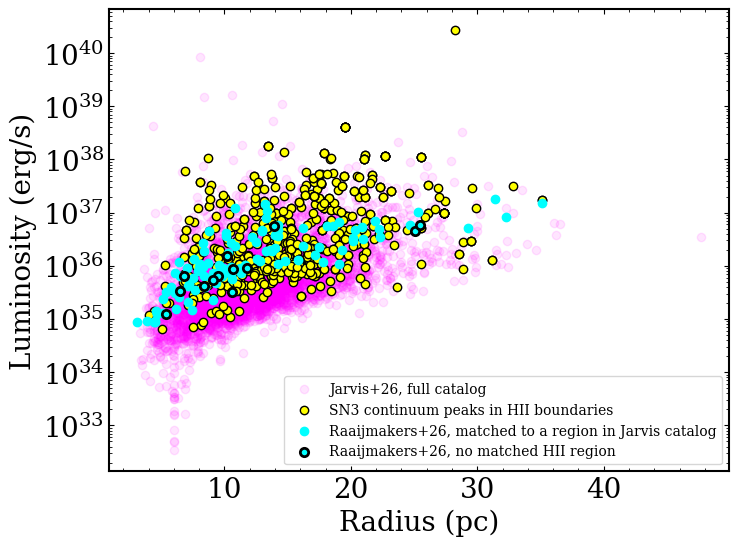

In [18]:
# Convert single-star fluxes to luminosities
single_star_L = (
    10 ** single_star_regions["log_Halpha_erg_cm-2_s-1"]
    * 4
    * np.pi
    * (M33_DISTANCE_PC * 3.086e18) ** 2
)

# Masks for matched and unmatched regions
matched = single_star_regions["region_id"].notna()
unmatched = single_star_regions["region_id"].isna()

# Plot luminosity vs radius
plt.figure(figsize=(8, 6))

plt.scatter(
    cat["R_c_pc"],
    cat["L_Halpha_bgsub"],
    c="magenta",
    alpha=0.1,
    label="Jarvis+26, full catalog",
)

# Halpha luminosity and radius for our regions that contain SN3 continuum peaks
plt.scatter(
    sn3_peak_matches["R_c_pc"],
    sn3_peak_matches["L_Halpha_bgsub"],
    c="yellow",
    edgecolor='k',
    linewidths=1,
    label="SN3 continuum peaks in HII boundaries",
)

plt.scatter(
    single_star_regions.loc[matched, "Radius_pc"],
    single_star_L.loc[matched],
    c="cyan",
    label="Raaijmakers+26, matched to a region in Jarvis catalog",
)

plt.scatter(
    single_star_regions.loc[unmatched, "Radius_pc"],
    single_star_L.loc[unmatched],
    c="cyan",
    edgecolor='k',
    linewidths=2,
    label="Raaijmakers+26, no matched HII region",
)




plt.xlabel("Radius (pc)")
plt.ylabel("Luminosity (erg/s)")
plt.yscale("log")
plt.legend(fontsize=10, loc="lower right")
plt.savefig("plots/m33_single_star_nebulae_luminosity_vs_radius.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
sn3_peak_matches


,field,region_number,region_id,x_px,y_px,RA_deg,Dec_deg,continuum_peak_value,threshold_sigma,min_distance_px,R_c_pc,L_Halpha_bgsub,log_L_Halpha_bgsub
0,NE,472,NE_0472,742.0,1407.0,23.635058,30.782909,4.558248e-17,8.0,3,19.544760,4.136183e+38,38.616600
1,NE,488,NE_0488,734.0,1422.0,23.635876,30.784265,2.849237e-17,8.0,3,8.922213,3.318193e+37,37.520902
2,NE,558,NE_0558,1763.0,1509.0,23.528102,30.790941,2.539357e-17,8.0,3,17.890835,1.299953e+38,38.113928
3,NE,220,NE_0220,1126.0,895.0,23.595539,30.736472,2.175679e-17,8.0,3,7.618790,4.983225e+35,35.697510
4,NE,469,NE_0469,702.0,1401.0,23.639250,30.782412,2.004292e-17,8.0,3,13.424562,1.808269e+38,38.257263
...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,SW,827,SW_0827,993.0,1696.0,23.395355,30.608361,2.279422e-18,8.0,3,17.906278,1.515036e+37,37.180423
596,SW,822,SW_0822,950.0,1690.0,23.399853,30.607868,2.278857e-18,8.0,3,19.259836,3.219001e+37,37.507721
597,F6,25,F6_0025,86.0,176.0,23.426081,30.789912,7.295549e-18,8.0,3,4.049148,1.172760e+35,35.069209
598,F6,152,F6_0152,157.0,702.0,23.418328,30.836130,3.203905e-18,8.0,3,16.048976,2.676277e+35,35.427531


In [14]:
for col in single_star_regions.columns:
    print(col)

ID
Field
Radius_pc
log_ne_cm-3
log_ne_uncertainty
log_ne_is_upper_limit
log_Halpha_erg_cm-2_s-1
FUV
NUV
F275W
F336W
F475W
F814W
F110W
F160W
source_id
RA_deg
Dec_deg
field
region_number
region_id
source_x_px
source_y_px
radius_px
hii_RA_deg
hii_Dec_deg
catalog_R_c_pc


In [15]:
single_star_regions["region_id"]

0          NaN
1      SW_0378
2      NW_0462
3      SW_0897
4      NW_0140
        ...   
111    NE_0674
112    NE_0364
113    NE_0362
114    NE_0286
115    NE_0321
Name: region_id, Length: 116, dtype: object

In [16]:
# number of single star regions with a boundary cross match

single_star_with_boundary = single_star_regions.dropna(subset=['region_id']).copy()
print(f'Number of single-star nebulae with a matched M33 HII region boundary: {len(single_star_with_boundary)} / {len(single_star_regions)} ({len(single_star_with_boundary) / len(single_star_regions):.1%})')

phatter_inside_count = int(phatter_catalog_regions['inside_phatter_footprint'].sum())
print(
    f'Number of M33 HII catalog regions inside the PHATTER ACS/WFC footprint: '
    f'{phatter_inside_count} / {len(phatter_catalog_regions)} '
    f'({phatter_inside_count / len(phatter_catalog_regions):.1%})'
)

matched_unique_boundaries = single_star_with_boundary[['field', 'region_number', 'region_id']].drop_duplicates('region_id').copy()
cat_match_lookup = cat.copy()
cat_match_lookup['field'] = cat_match_lookup['Field'].astype(str).str.upper()
cat_match_lookup['region_number'] = pd.to_numeric(cat_match_lookup['ID'], errors='coerce')
class_col = 'BPT_class_sum_dered' if 'BPT_class_sum_dered' in cat_match_lookup.columns else 'BPT_class'
lookup_cols = ['field', 'region_number', 'selected_star_forming']
if class_col in cat_match_lookup.columns:
    lookup_cols.append(class_col)
matched_unique_boundaries = matched_unique_boundaries.merge(
    cat_match_lookup[lookup_cols], on=['field', 'region_number'], how='left'
)
matched_unique_boundaries['selected_star_forming'] = matched_unique_boundaries['selected_star_forming'].fillna(False).astype(bool)
n_matched_unique = len(matched_unique_boundaries)
n_matched_sf = int(matched_unique_boundaries['selected_star_forming'].sum())
n_matched_other = n_matched_unique - n_matched_sf
print(
    f'Unique matched M33 HII boundaries classified as star-forming: '
    f'{n_matched_sf} / {n_matched_unique}; other/non-star-forming: {n_matched_other} / {n_matched_unique}'
)
if class_col in matched_unique_boundaries.columns:
    print('BPT classes for unique matched M33 HII boundaries:')
    for bpt_class, count in matched_unique_boundaries[class_col].fillna('Unclassified').value_counts().sort_index().items():
        print(f'  {bpt_class}: {int(count)}')


Number of single-star nebulae with a matched M33 HII region boundary: 103 / 116 (88.8%)
Number of M33 HII catalog regions inside the PHATTER ACS/WFC footprint: 3112 / 5893 (52.8%)
Unique matched M33 HII boundaries classified as star-forming: 93 / 100; other/non-star-forming: 7 / 100
BPT classes for unique matched M33 HII boundaries:
  AGN/Shock: 3
  Star-forming: 93
  Unclassified: 4
